In [2]:
import smact
from smact import Element

# 定义前 118 号元素的符号
ALL_ELEMENTS = [
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
    "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"
]

print(f"{'Symbol':<6} | {'Status':<10} | {'Oxidation States'}")
print("-" * 40)

problematic_elements = []

for symbol in ALL_ELEMENTS:
    try:
        # 尝试获取元素对象
        el = Element(symbol)
        ox_states = el.oxidation_states

        if ox_states is None:
            status = "NONE" # 这就是导致报错的罪魁祸首
            problematic_elements.append(symbol)
        elif len(ox_states) == 0:
            status = "EMPTY"
            problematic_elements.append(symbol)
        else:
            status = "OK"

        print(f"{symbol:<6} | {status:<10} | {ox_states}")

    except Exception as e:
        # 如果 smact 根本不认识这个元素（比如超重元素）
        print(f"{symbol:<6} | {'ERROR':<10} | {str(e)}")
        problematic_elements.append(symbol)

print("\n" + "="*40)
print(problematic_elements)

Symbol | Status     | Oxidation States
----------------------------------------
H      | OK         | [-1, 1]
He     | NONE       | None
Li     | OK         | [1]
Be     | OK         | [2]
B      | OK         | [-3, -2, -1, 1, 2, 3]
C      | OK         | [-4, -3, -2, -1, 1, 2, 3, 4]
N      | OK         | [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
O      | OK         | [-2, -1]
F      | OK         | [-1]
Ne     | NONE       | None
Na     | OK         | [1]
Mg     | OK         | [2]
Al     | OK         | [3]
Si     | OK         | [-4, -3, -2, -1, 2, 3, 4]
P      | OK         | [-3, -2, -1, 1, 2, 3, 4, 5]
S      | OK         | [-2, -1, 1, 2, 3, 4, 5, 6]
Cl     | OK         | [-1, 1, 3, 5, 7]
Ar     | NONE       | None
K      | OK         | [1]
Ca     | OK         | [2]
Sc     | OK         | [1, 2, 3]
Ti     | OK         | [2, 3, 4]
V      | OK         | [1, 2, 3, 4, 5]
Cr     | OK         | [1, 2, 3, 4, 5, 6]
Mn     | OK         | [-1, 1, 2, 3, 4, 5, 6, 7]
Fe     | OK         | [1, 2, 3, 4, 5, 6

In [1]:
import pandas as pd
import ast
import os

# 1. 完整的原子序数映射表 (Z=1 to Z=118)
ELEMENT_TO_Z = {
    'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10,
    'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15, 'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20,
    'Sc': 21, 'Ti': 22, 'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26, 'Co': 27, 'Ni': 28, 'Cu': 29, 'Zn': 30,
    'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34, 'Br': 35, 'Kr': 36, 'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40,
    'Nb': 41, 'Mo': 42, 'Tc': 43, 'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50,
    'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54, 'Cs': 55, 'Ba': 56, 'La': 57, 'Ce': 58, 'Pr': 59, 'Nd': 60,
    'Pm': 61, 'Sm': 62, 'Eu': 63, 'Gd': 64, 'Tb': 65, 'Dy': 66, 'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70,
    'Lu': 71, 'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77, 'Pt': 78, 'Au': 79, 'Hg': 80,
    'Tl': 81, 'Pb': 82, 'Bi': 83, 'Po': 84, 'At': 85, 'Rn': 86, 'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90,
    'Pa': 91, 'U': 92, 'Np': 93, 'Pu': 94, 'Am': 95, 'Cm': 96, 'Bk': 97, 'Cf': 98, 'Es': 99, 'Fm': 100,
    # 超过 100 的元素
    'Md': 101, 'No': 102, 'Lr': 103, 'Rf': 104, 'Db': 105, 'Sg': 106, 'Bh': 107, 'Hs': 108, 'Mt': 109,
    'Ds': 110, 'Rg': 111, 'Cn': 112, 'Nh': 113, 'Fl': 114, 'Mc': 115, 'Lv': 116, 'Ts': 117, 'Og': 118
}

def check_file(filename):
    print(f"正在检查文件: {filename} ...")
    if not os.path.exists(filename):
        print(f"  [Error] 文件未找到: {filename}")
        return

    try:
        df = pd.read_csv(filename)
        if 'elements' not in df.columns:
            print(f"  [Error] 列名 'elements' 不存在于 {filename}")
            return

        found_issues = False
        max_z_found = 0

        for index, row in df.iterrows():
            try:
                # 解析字符串列表，例如 "['Co', 'O']" -> ['Co', 'O']
                elements_list = ast.literal_eval(row['elements'])

                for el in elements_list:
                    if el not in ELEMENT_TO_Z:
                        print(f"  [Warning] 行 {index}: 未知元素符号 '{el}'")
                        continue

                    z = ELEMENT_TO_Z[el]
                    if z > max_z_found:
                        max_z_found = z

                    if z > 100:
                        print(f"  [ALERT] 发现超标元素! 文件: {filename}, 行: {index}, ID: {row.get('material_id', 'N/A')}")
                        print(f"          元素: {el} (Z={z})")
                        found_issues = True

            except Exception as e:
                print(f"  [Error] 解析第 {index} 行时出错: {e}")

        if not found_issues:
            print(f"  ✅ 检查完成。没有发现 Z > 100 的元素。")
        else:
            print(f"  ❌ 检查完成。发现了 Z > 100 的元素 (见上文)。")

        print(f"  (该文件中最大的原子序数是: {max_z_found})\n")

    except Exception as e:
        print(f"读取文件 {filename} 失败: {e}")

if __name__ == "__main__":
    files_to_check = ['../data/mp_20/train.csv', '../data/mp_20/val.csv', '../data/mp_20/test.csv']

    print("================ 开始检查原子序数 ================")
    print(f"检查标准: 原子序数是否 > 100 (即 Md, No, Lr...)\n")

    for f in files_to_check:
        check_file(f)

    print("================ 检查结束 ================")

================ 开始检查原子序数 ================
检查标准: 原子序数是否 > 100 (即 Md, No, Lr...)

正在检查文件: ../data/mp_20/train.csv ...
  ✅ 检查完成。没有发现 Z > 100 的元素。
  (该文件中最大的原子序数是: 94)

正在检查文件: ../data/mp_20/val.csv ...
  ✅ 检查完成。没有发现 Z > 100 的元素。
  (该文件中最大的原子序数是: 94)

正在检查文件: ../data/mp_20/test.csv ...
  ✅ 检查完成。没有发现 Z > 100 的元素。
  (该文件中最大的原子序数是: 94)

================ 检查结束 ================


# 查看生成的结构

In [1]:
# python
from pathlib import Path
import torch
import numpy as np
from tqdm import tqdm

pt_path = Path(r"../output/singlerun/2025-12-13/01-08-21-mp_20_bg/eval_gen_mp_20_bg.pt")

# 1) 加载到 CPU（如果原来保存在 GPU 上，这能避免 device 错误）
data = torch.load(pt_path, map_location="cpu", weights_only=False)

# 2) 列出所有键
print("keys:", list(data.keys()))

# 3) 打印每个张量的类型和形状，收集 tensor 键用于后续保存
tensor_items = {}
for k, v in data.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: tensor shape={v.shape} dtype={v.dtype}")
        tensor_items[k] = v
    else:
        # 非张量（例如 argparse.Namespace、dict、list 等）
        print(f"{k}: type={type(v)} (skip saving as .npz)")


keys: ['eval_setting', 'frac_coords', 'num_atoms', 'atom_types', 'lengths', 'angles']
eval_setting: type=<class 'argparse.Namespace'> (skip saving as .npz)
frac_coords: tensor shape=torch.Size([187888, 3]) dtype=torch.float32
num_atoms: tensor shape=torch.Size([10000]) dtype=torch.int64
atom_types: tensor shape=torch.Size([187888]) dtype=torch.int64
lengths: tensor shape=torch.Size([10000, 3]) dtype=torch.float32
angles: tensor shape=torch.Size([10000, 3]) dtype=torch.float32


In [2]:
data['time'] / 3600

KeyError: 'time'

In [3]:
data['input_data_batch'][0].spacegroup

KeyError: 'input_data_batch'

In [12]:
import pandas as pd

df = pd.read_csv("../data/c2db_51/train.csv")
df.columns

Index(['index', 'uid', 'unique_id', 'lgnum', 'layergroup', 'thickness', 'gap',
       'energy', 'natoms', 'ehull', 'hform', 'magmoms', 'formula', 'elements',
       'cif', 'pbc'],
      dtype='object')

In [13]:
selected = ['gap', 'ehull', 'hform', 'energy']
selected = [c for c in selected if c in df.columns]
if not selected:
    raise ValueError("没有找到指定列，请检查列名")

means = df[selected].mean(skipna=True)
std_sample = df[selected].std(skipna=True)      # ddof=1，样本标准差
std_pop = df[selected].std(ddof=0, skipna=True) # ddof=0，总体标准差

print("Selected columns stats:")
print(pd.DataFrame({'mean': means, 'std_sample': std_sample, 'std_pop': std_pop}))


Selected columns stats:
             mean  std_sample    std_pop
gap      0.805191    1.227997   1.227879
ehull    0.224902    0.224261   0.224250
hform   -0.640786    0.683464   0.683430
energy -43.876245   28.653333  28.651921


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
train_csv = "../data/mp_20/train.csv"
val_csv   = "../data/mp_20/val.csv"
test_csv  = "../data/mp_20/test.csv"

output_dir = "../assets/data/mp_20"
os.makedirs(output_dir, exist_ok=True)

properties = [
    "formation_energy_per_atom",
    "band_gap",
    "e_above_hull",
]


In [3]:
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)
df_test = pd.read_csv(test_csv)

In [4]:
df_train.columns

Index(['Unnamed: 0', 'material_id', 'formation_energy_per_atom', 'band_gap',
       'pretty_formula', 'e_above_hull', 'elements', 'cif',
       'spacegroup.number'],
      dtype='object')

In [10]:
df_train['pretty_formula'][0]

'Na3MnCoNiO6'

In [8]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

dfs = {"train": df_train, "val": df_val, "test": df_test}
properties = ["formation_energy_per_atom", "band_gap", "e_above_hull"]

output_dir = Path("../assets/data/mp_20")
output_dir.mkdir(parents=True, exist_ok=True)

colors = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#2ca02c"}
alphas = {
    "train": 0.35,
    "val":   0.55,
    "test":  0.75,
}

bins = 50

for prop in properties:
    values_list = []
    for df in dfs.values():
        if prop in df.columns:
            values_list.append(df[prop].dropna().values)

    if not values_list:
        continue

    all_values = np.concatenate(values_list)
    if all_values.size == 0:
        continue

    vmin, vmax = np.min(all_values), np.max(all_values)
    margin = (vmax - vmin) * 0.02 if vmax > vmin else 0.5
    hist_range = (vmin - margin, vmax + margin)

    plt.figure(figsize=(8, 5))

    for split, df in dfs.items():
        if prop not in df.columns:
            continue
        data = df[prop].dropna().values
        if data.size == 0:
            continue

        counts, edges = np.histogram(
            data, bins=bins, range=hist_range
        )

        plt.bar(
            edges[:-1],
            counts,
            width=np.diff(edges),
            align="edge",
            alpha=alphas.get(split, 0.5),
            color=colors.get(split),
            label=f"{split} (n={data.size})"
        )

    plt.xlabel(prop)
    plt.ylabel("Count")
    plt.title(f"{prop} distribution (train/val/test)")
    plt.legend()
    plt.grid(alpha=0.25)

    save_path = output_dir / f"{prop}_hist.png"
    plt.savefig(save_path, dpi=150)  # ← 降低 dpi
    plt.close()

    print(f"Saved {save_path}")


Saved ..\assets\data\mp_20\formation_energy_per_atom_hist.png
Saved ..\assets\data\mp_20\band_gap_hist.png
Saved ..\assets\data\mp_20\e_above_hull_hist.png


In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt

def count_unique_elements(formula):
    """
    使用正则表达式查找化学式中的元素符号。
    逻辑：匹配一个大写字母，后面可选跟一个小写字母。
    例如: "BaTiO3" -> ['Ba', 'Ti', 'O'] -> 数量 3
    """
    if not isinstance(formula, str):
        return 0
    # 正则表达式：[A-Z]匹配大写，[a-z]*匹配0个或多个小写
    elements = re.findall(r'[A-Z][a-z]*', formula)
    return len(set(elements)) # 使用set去重（虽然pretty_formula通常已经唯一，但保险起见）

# 2. 计算每个结构独特的元素个数，并添加到 DataFrame
new_prop = "n_elements" # 新的统计列名

print("正在统计元素个数...")
for split, df in dfs.items():
    if "pretty_formula" in df.columns:
        #应用函数生成新列
        df[new_prop] = df["pretty_formula"].apply(count_unique_elements)
    else:
        print(f"Warning: 'pretty_formula' not found in {split} set.")

values_list = []
for df in dfs.values():
    if new_prop in df.columns:
        values_list.append(df[new_prop].dropna().values)

if values_list:
    all_values = np.concatenate(values_list)
    vmin, vmax = int(np.min(all_values)), int(np.max(all_values))

    bins_int = np.arange(vmin, vmax + 2)

    plt.figure(figsize=(8, 5))

    for split, df in dfs.items():
        if new_prop not in df.columns:
            continue

        data = df[new_prop].dropna().values

        # 计算直方图
        counts, edges = np.histogram(data, bins=bins_int)

        centers = edges[:-1]

        plt.bar(
            centers,
            counts,
            width=0.8,
            align="center",
            alpha=alphas.get(split, 0.5),
            color=colors.get(split),
            label=f"{split} (n={data.size})"
        )

    plt.xlabel("Number of Unique Elements")
    plt.ylabel("Count")
    plt.title("Distribution of Elements per Structure (Unary/Binary/Ternary...)")

    plt.xticks(np.arange(vmin, vmax + 1))

    plt.legend()
    plt.grid(alpha=0.25, axis='y') # 只显示Y轴网格更整洁

    save_path = output_dir / f"{new_prop}_hist.png"
    plt.savefig(save_path, dpi=150)
    plt.close()

    print(f"Saved {save_path}")
else:
    print("没有找到有效的数据进行绘图。")

正在统计元素个数...
Saved ..\assets\data\mp_20\n_elements_hist.png


In [13]:
import matplotlib.patches as mpatches

# 1. 定义晶系与空间群编号的对应范围 (国际晶体学表)
crystal_systems = [
    ("Triclinic", (1, 2), "#e0e0e0"),       # 三斜: 灰
    ("Monoclinic", (3, 15), "#ffcccc"),     # 单斜: 浅红
    ("Orthorhombic", (16, 74), "#ccffcc"),  # 正交: 浅绿
    ("Tetragonal", (75, 142), "#ccccff"),   # 四方: 浅蓝
    ("Trigonal", (143, 167), "#ffffcc"),    # 三方: 浅黄
    ("Hexagonal", (168, 194), "#ffccff"),   # 六方: 浅紫
    ("Cubic", (195, 230), "#ccffff"),       # 立方: 浅青
]

sg_col = "spacegroup.number"

print("正在统计空间群分布...")

# 准备绘图，为了容纳230个数据点和文字，图片设宽一点
plt.figure(figsize=(15, 6))

# 2. 绘制背景分区 (Crystal System Partitions)
# 我们使用 axvspan 在背景画出彩色区块
for name, (start, end), color in crystal_systems:
    # 绘制矩形区域
    plt.axvspan(start - 0.5, end + 0.5, facecolor=color, alpha=0.3, edgecolor='none')

    # 在区域顶部添加文字标签 (根据区域宽度决定文字大小/旋转)
    center = (start + end) / 2
    width = end - start + 1

    # 只有当区域足够宽时才显示文字，或者对于窄区域(如Triclinic)进行特殊处理
    if width > 5:
        plt.text(center, plt.gca().get_ylim()[1], name,
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='black',
                 transform=plt.gca().get_xaxis_transform()) # 确保文字在坐标轴上方
    elif width <= 5 and name == "Triclinic":
         # 三斜太窄了，简写或略过，这里用首字母T
         plt.text(center, plt.gca().get_ylim()[1], "Tri",
                 ha='center', va='bottom', fontsize=8, rotation=90,
                 transform=plt.gca().get_xaxis_transform())

# 3. 绘制空间群直方图
# 每一个整数(1-230)作为一个bin
bins_sg = np.arange(1, 232) # [1, 2, ..., 231] -> 使得 edges 包含 1..230
hist_range = (0.5, 230.5)   # 让柱子居中

max_count = 0 # 用于调整y轴上限

for split, df in dfs.items():
    if sg_col not in df.columns:
        print(f"Warning: '{sg_col}' not found in {split}.")
        continue

    data = df[sg_col].dropna().values
    if data.size == 0:
        continue

    # 统计直方图
    counts, edges = np.histogram(data, bins=np.arange(0.5, 231.5, 1))

    max_count = max(max_count, counts.max())

    # 绘制柱状图
    # 这里我们把 edges 转换回整数中心位置
    centers = (edges[:-1] + edges[1:]) / 2

    plt.bar(
        centers,
        counts,
        width=1.0, # 柱子紧密相连
        align="center",
        alpha=alphas.get(split, 0.5),
        color=colors.get(split),
        label=f"{split} (n={data.size})"
    )

# 4. 图表装饰
plt.xlim(0, 231)
plt.ylim(0, max_count * 1.1) # 留出一点空间给背景文字
plt.xlabel("Space Group Number (1-230)")
plt.ylabel("Count")
# plt.title("Distribution of Space Groups with Crystal System Partitions")
plt.legend(loc="upper left") # 图例放左上，通常Triclinic/Monoclinic数量较少，遮挡风险小

# 优化 X 轴刻度：显示主要的分界点
boundary_ticks = [1] + [sys[1][1] for sys in crystal_systems]
# boundary_ticks = [1, 2, 15, 74, 142, 167, 194, 230]
plt.xticks(boundary_ticks, rotation=45)

plt.grid(axis='y', alpha=0.3)

save_path = output_dir / "diff_spacegroup_hist.png"
plt.tight_layout() # 防止文字溢出
plt.savefig(save_path, dpi=150)
plt.close()

print(f"Saved {save_path}")

print("\n--- Crystal System Statistics (Train Set) ---")
if 'train' in dfs and sg_col in dfs['train']:
    df_t = dfs['train']
    total = len(df_t)
    for name, (start, end), _ in crystal_systems:
        count = df_t[(df_t[sg_col] >= start) & (df_t[sg_col] <= end)].shape[0]
        print(f"{name:15s} ({start:3d}-{end:3d}): {count:5d} ({count/total*100:.1f}%)")

正在统计空间群分布...
Saved ..\assets\data\mp_20\spacegroup_hist.png

--- Crystal System Statistics (Train Set) ---
Triclinic       (  1-  2):  1146 (4.2%)
Monoclinic      (  3- 15):  4057 (15.0%)
Orthorhombic    ( 16- 74):  5272 (19.4%)
Tetragonal      ( 75-142):  4538 (16.7%)
Trigonal        (143-167):  3062 (11.3%)
Hexagonal       (168-194):  2859 (10.5%)
Cubic           (195-230):  6202 (22.9%)


正在加载和处理数据...
开始绘制目标属性(KDE密度)分布图...
已保存属性分布图: property_distributions.pdf/png


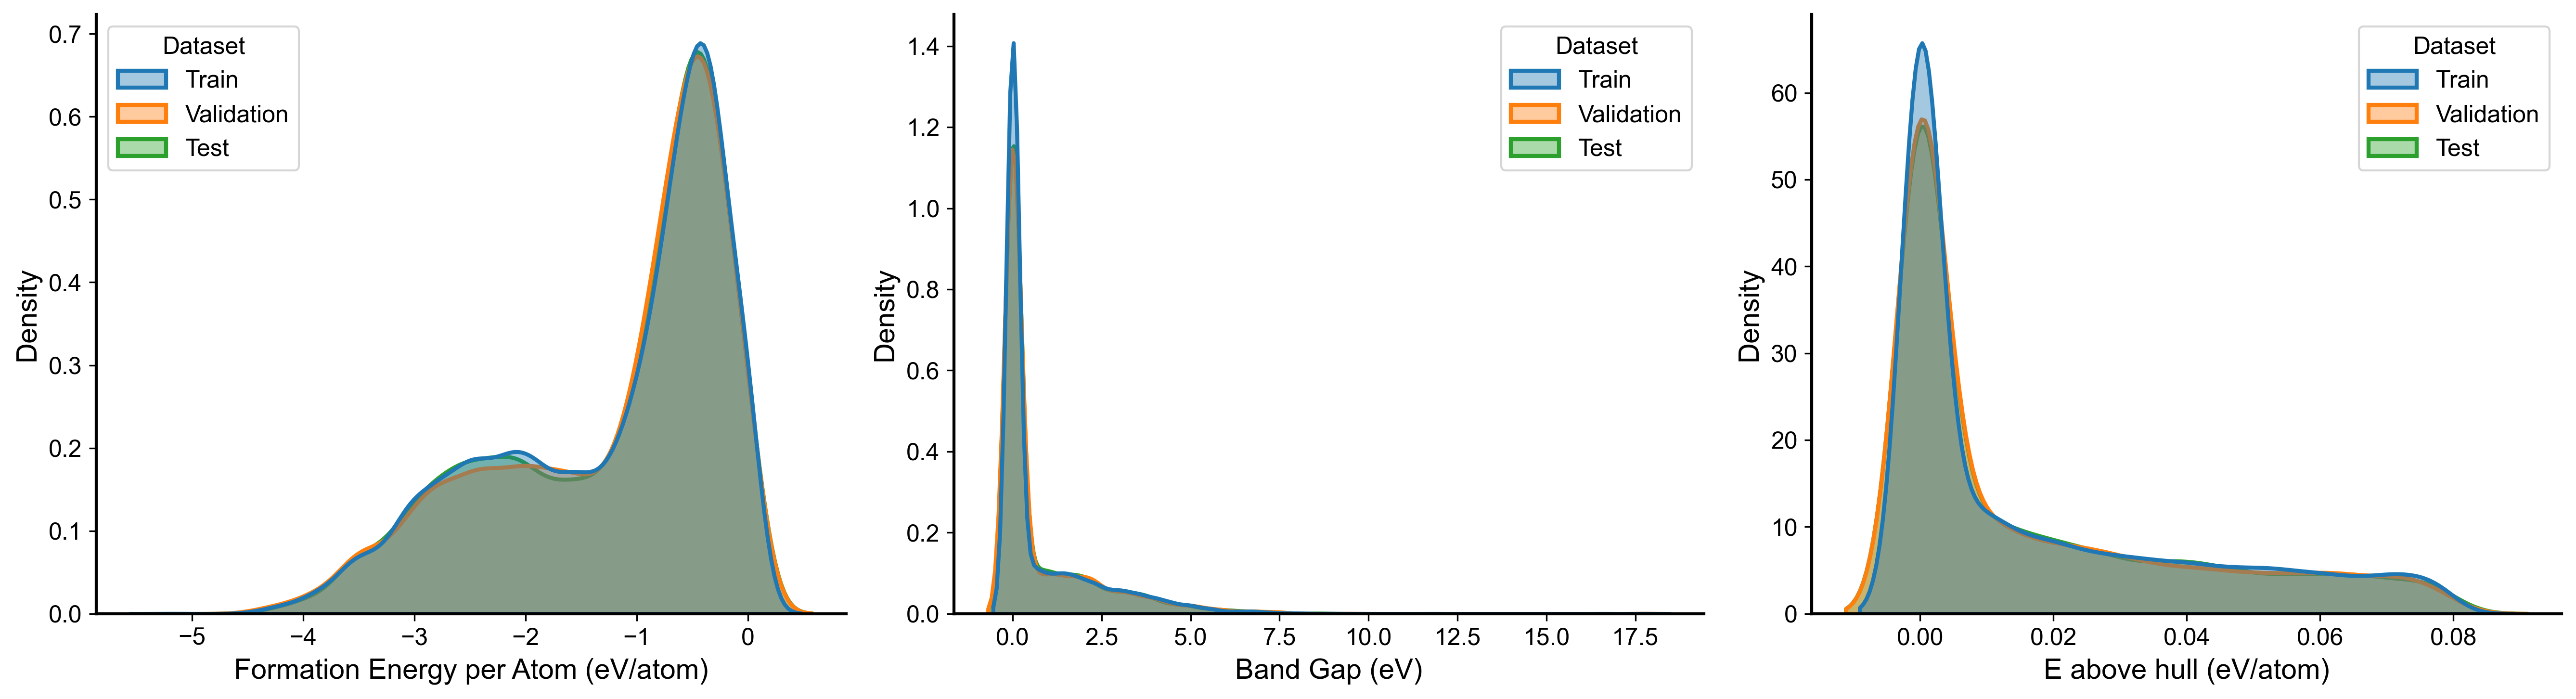

开始绘制目标属性(Boxplot箱线)图...


C:\Users\12931\AppData\Local\Temp\ipykernel_66780\3431203608.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\12931\AppData\Local\Temp\ipykernel_66780\3431203608.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\12931\AppData\Local\Temp\ipykernel_66780\3431203608.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


已保存属性箱线图: property_boxplots.pdf


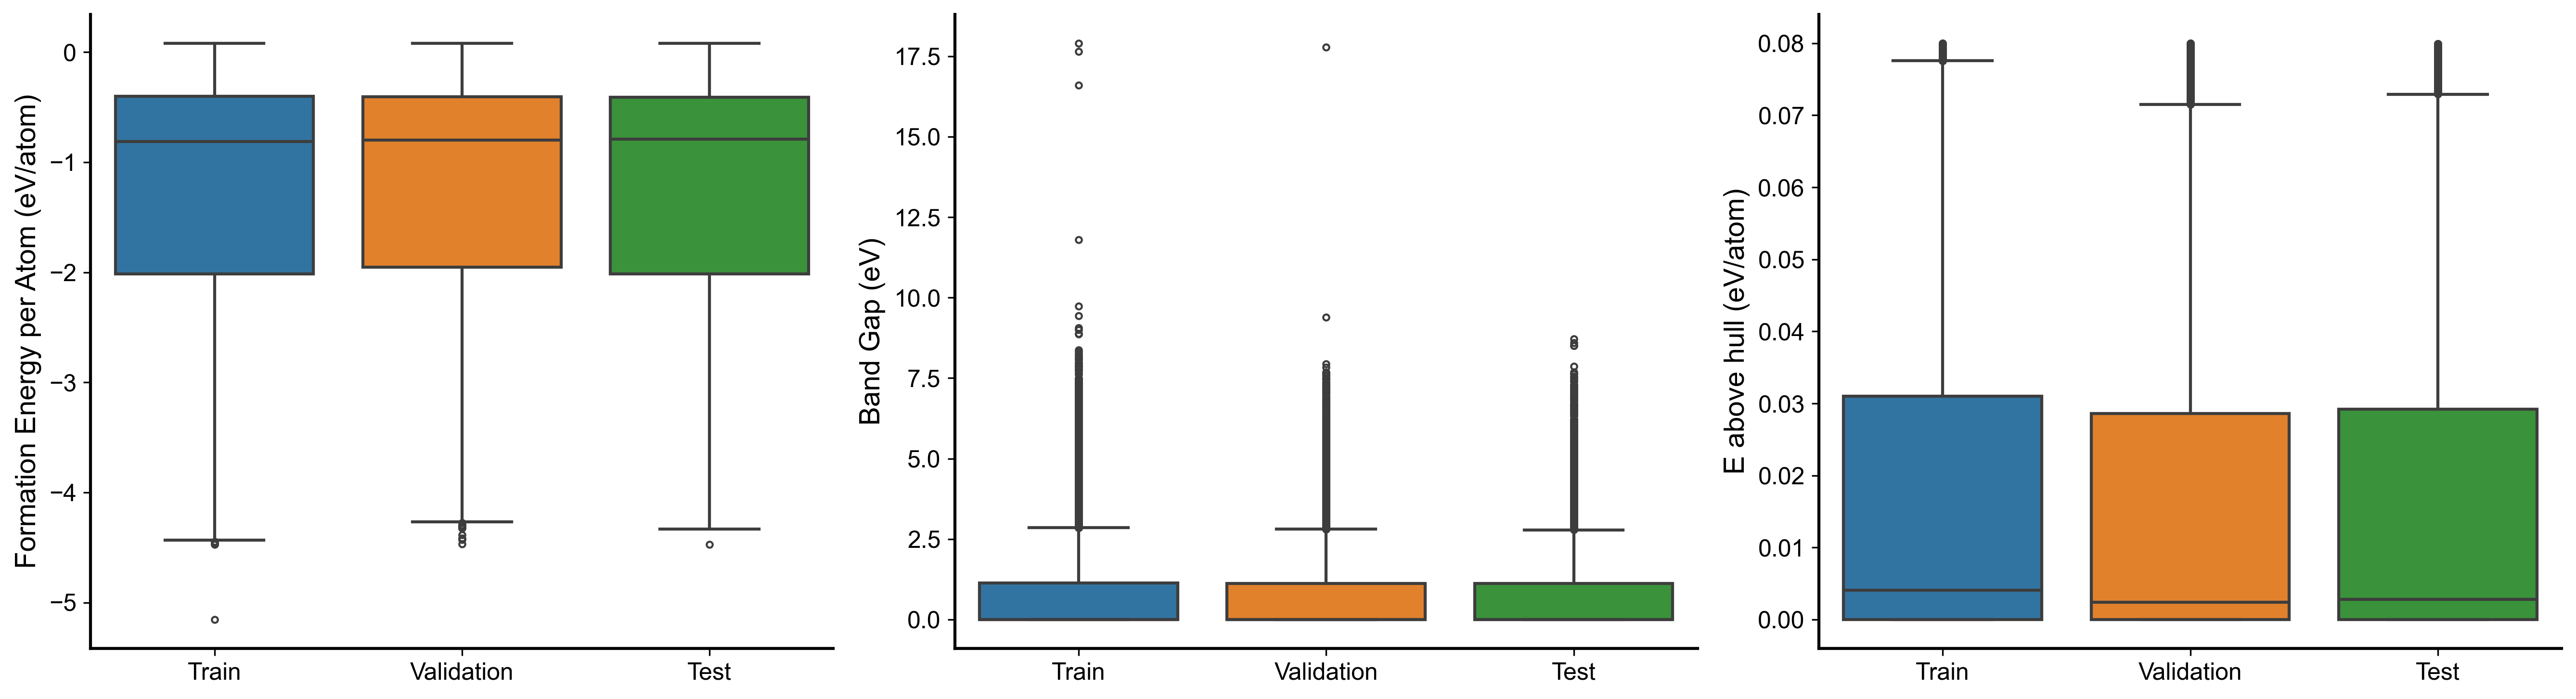

开始绘制目标属性(二维相关性)散点图...
已保存二维属性相关性图: property_correlation.pdf


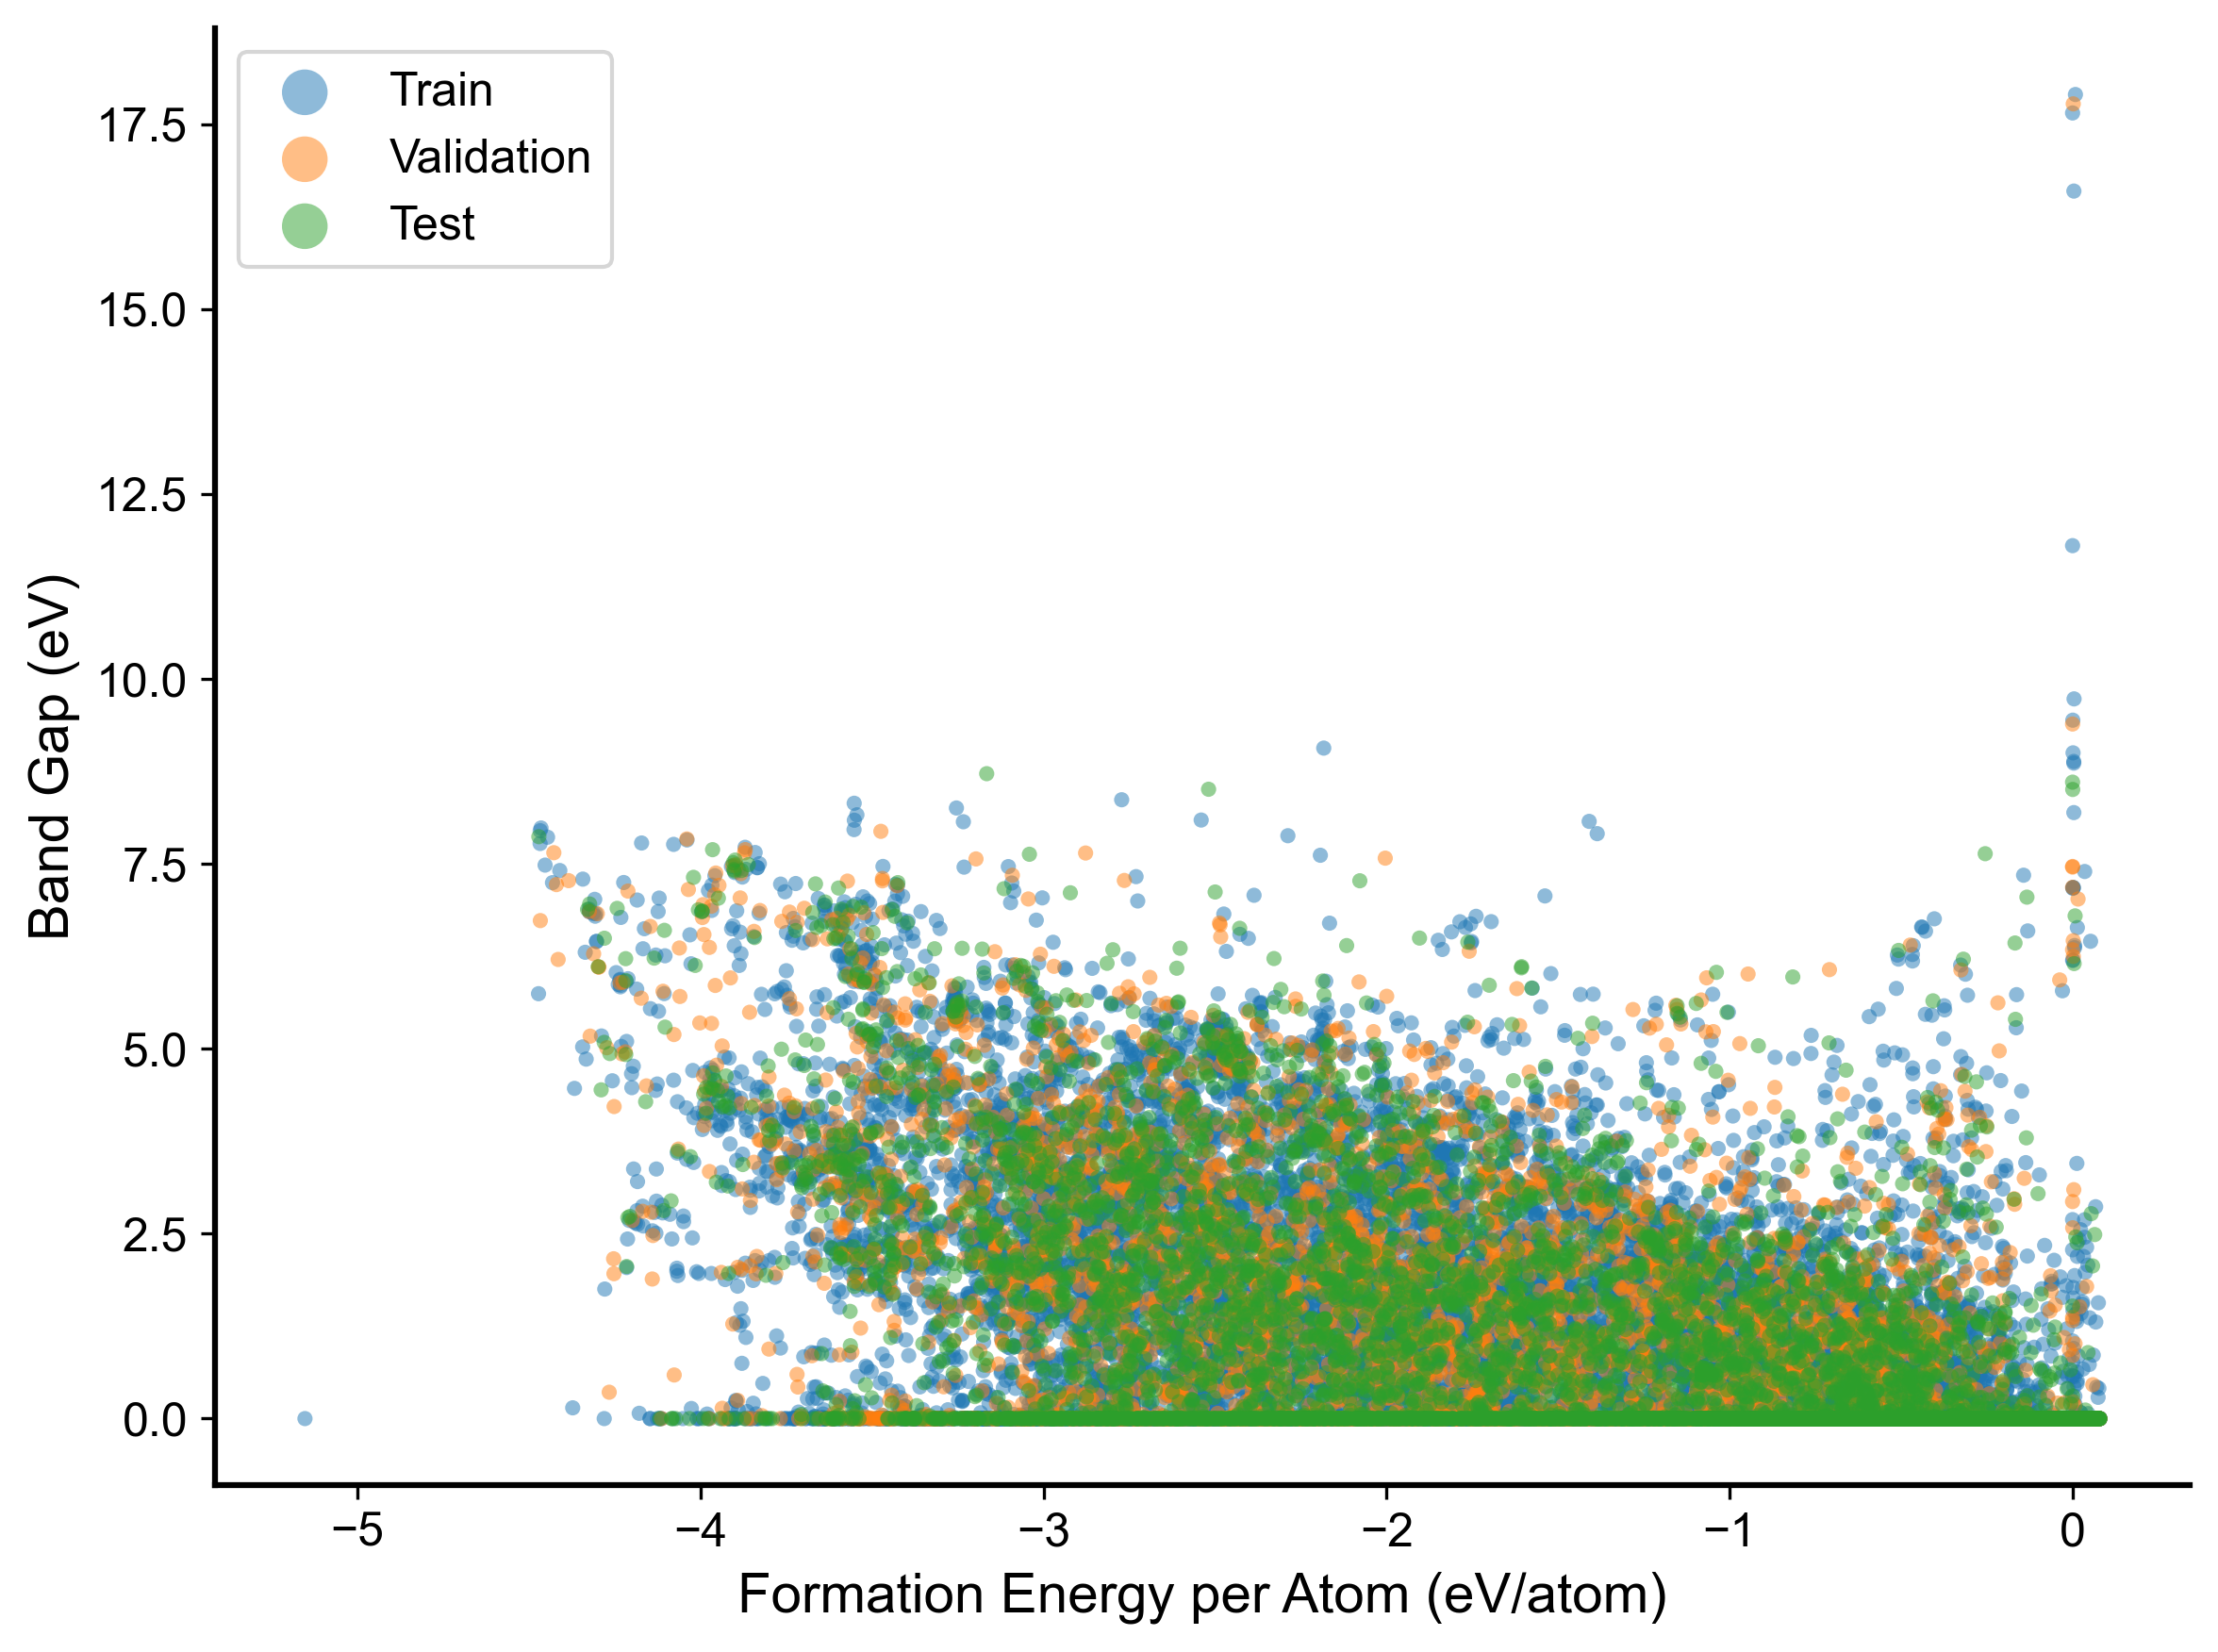

开始绘制空间群分布图...
已保存空间群分布图: spacegroup_distribution.pdf


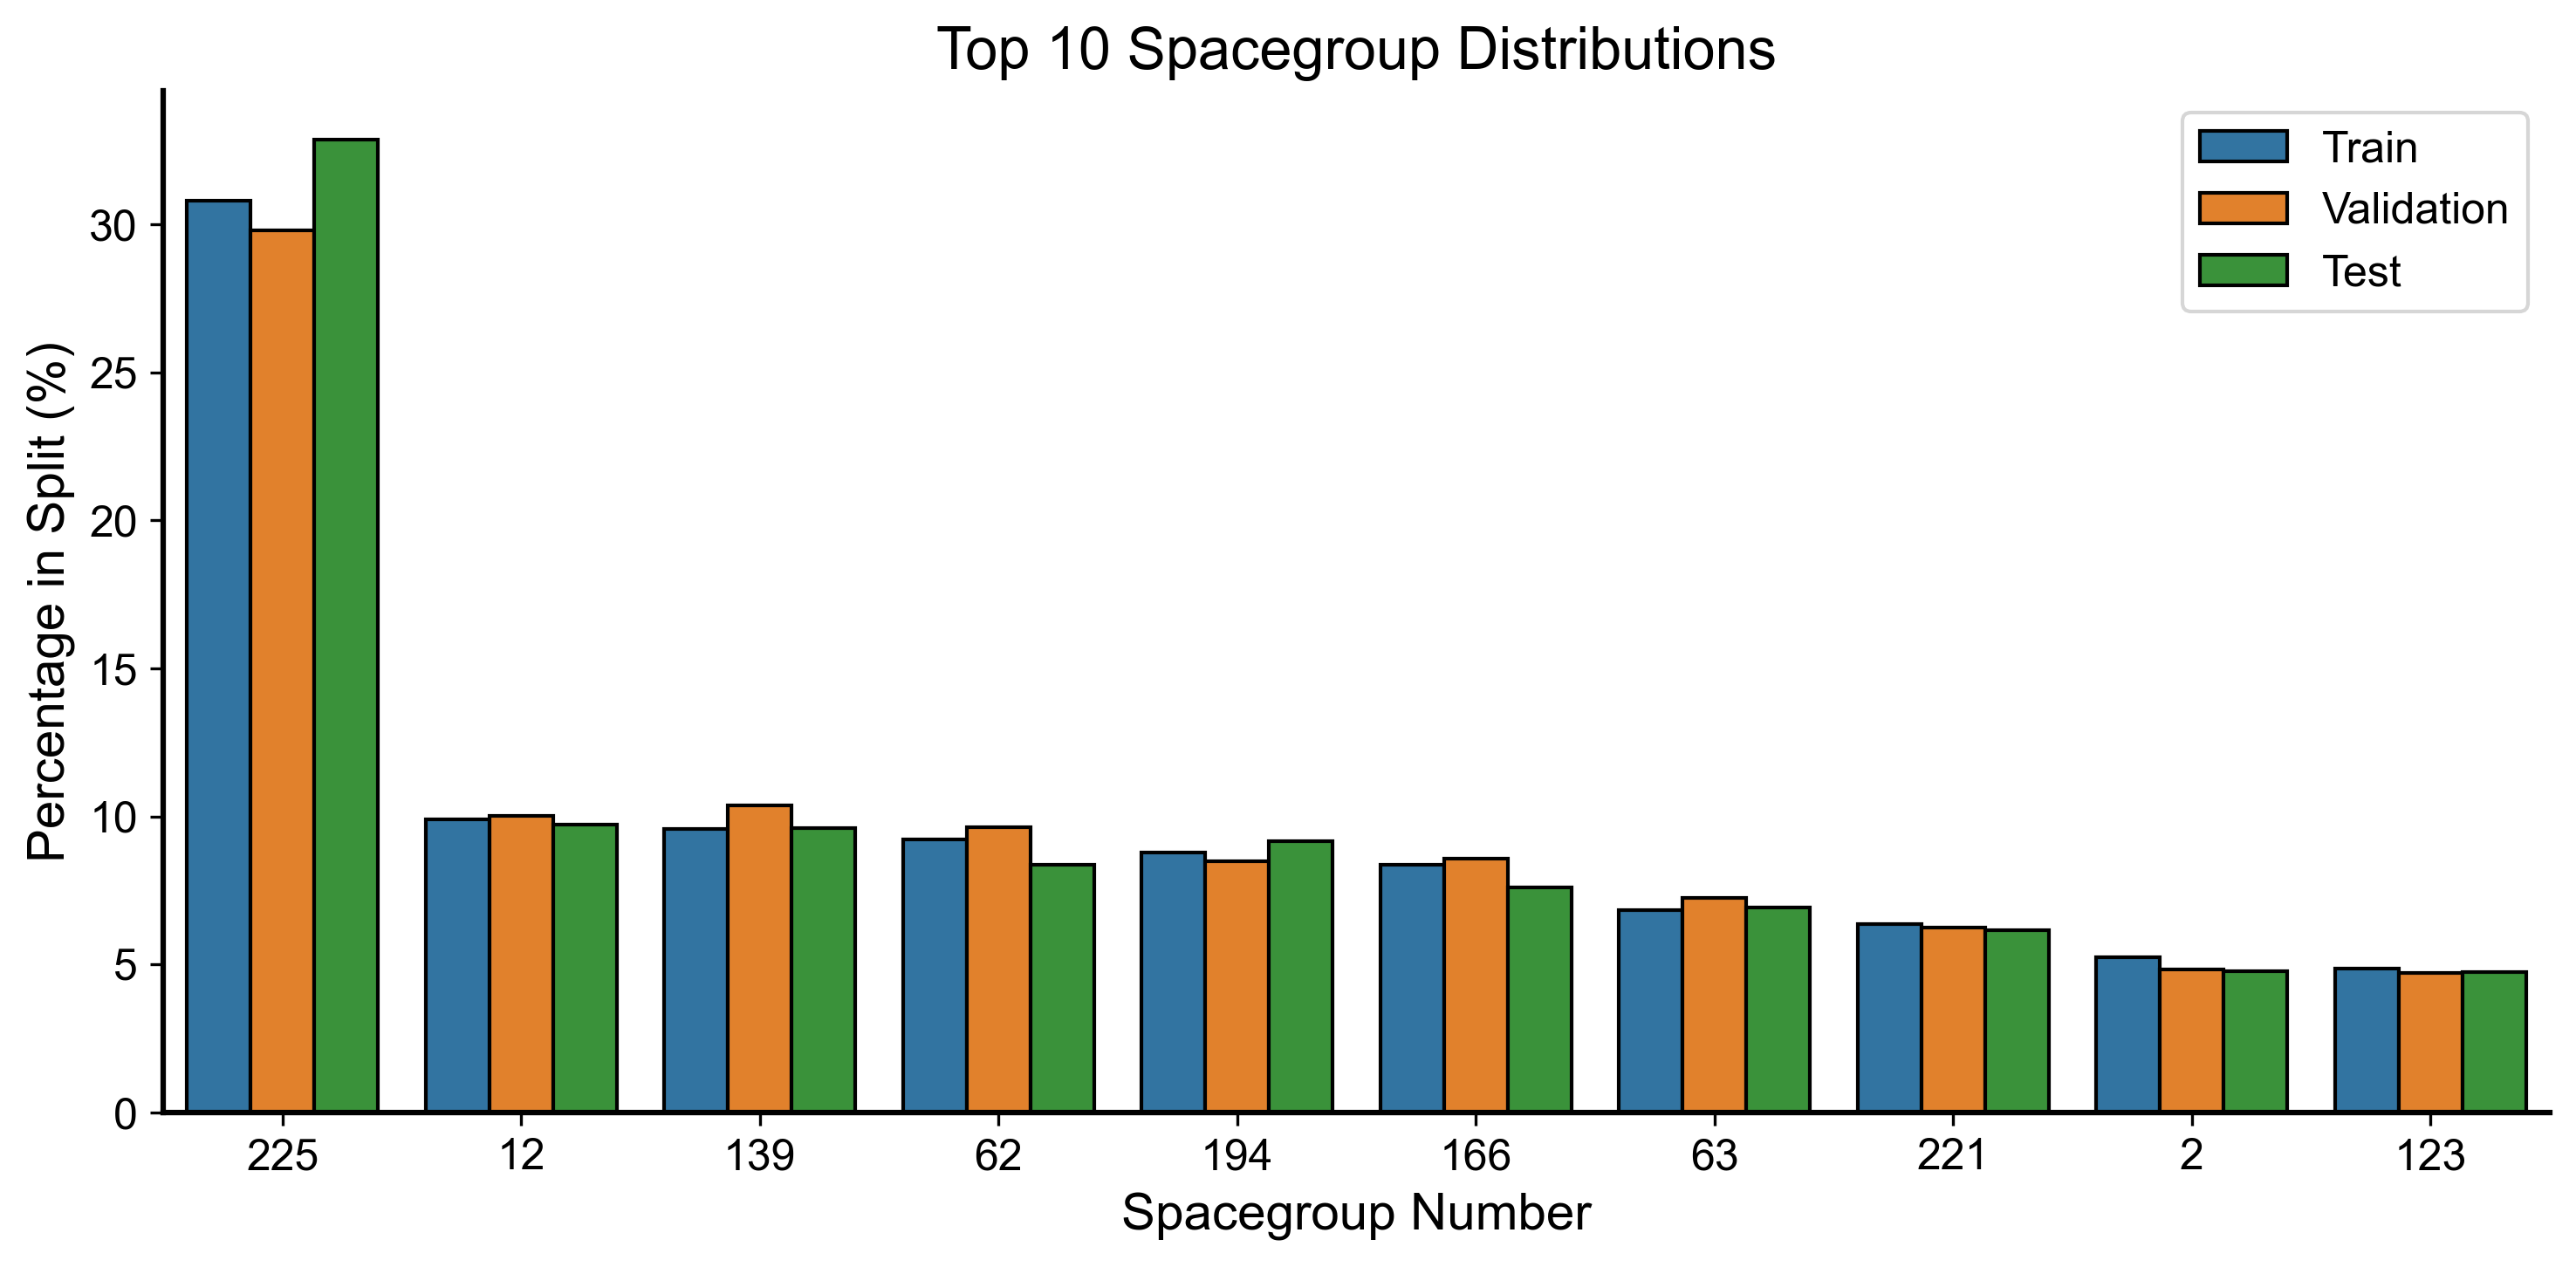

开始绘制元素频率分布图...
已保存元素分布图: elements_distribution.pdf


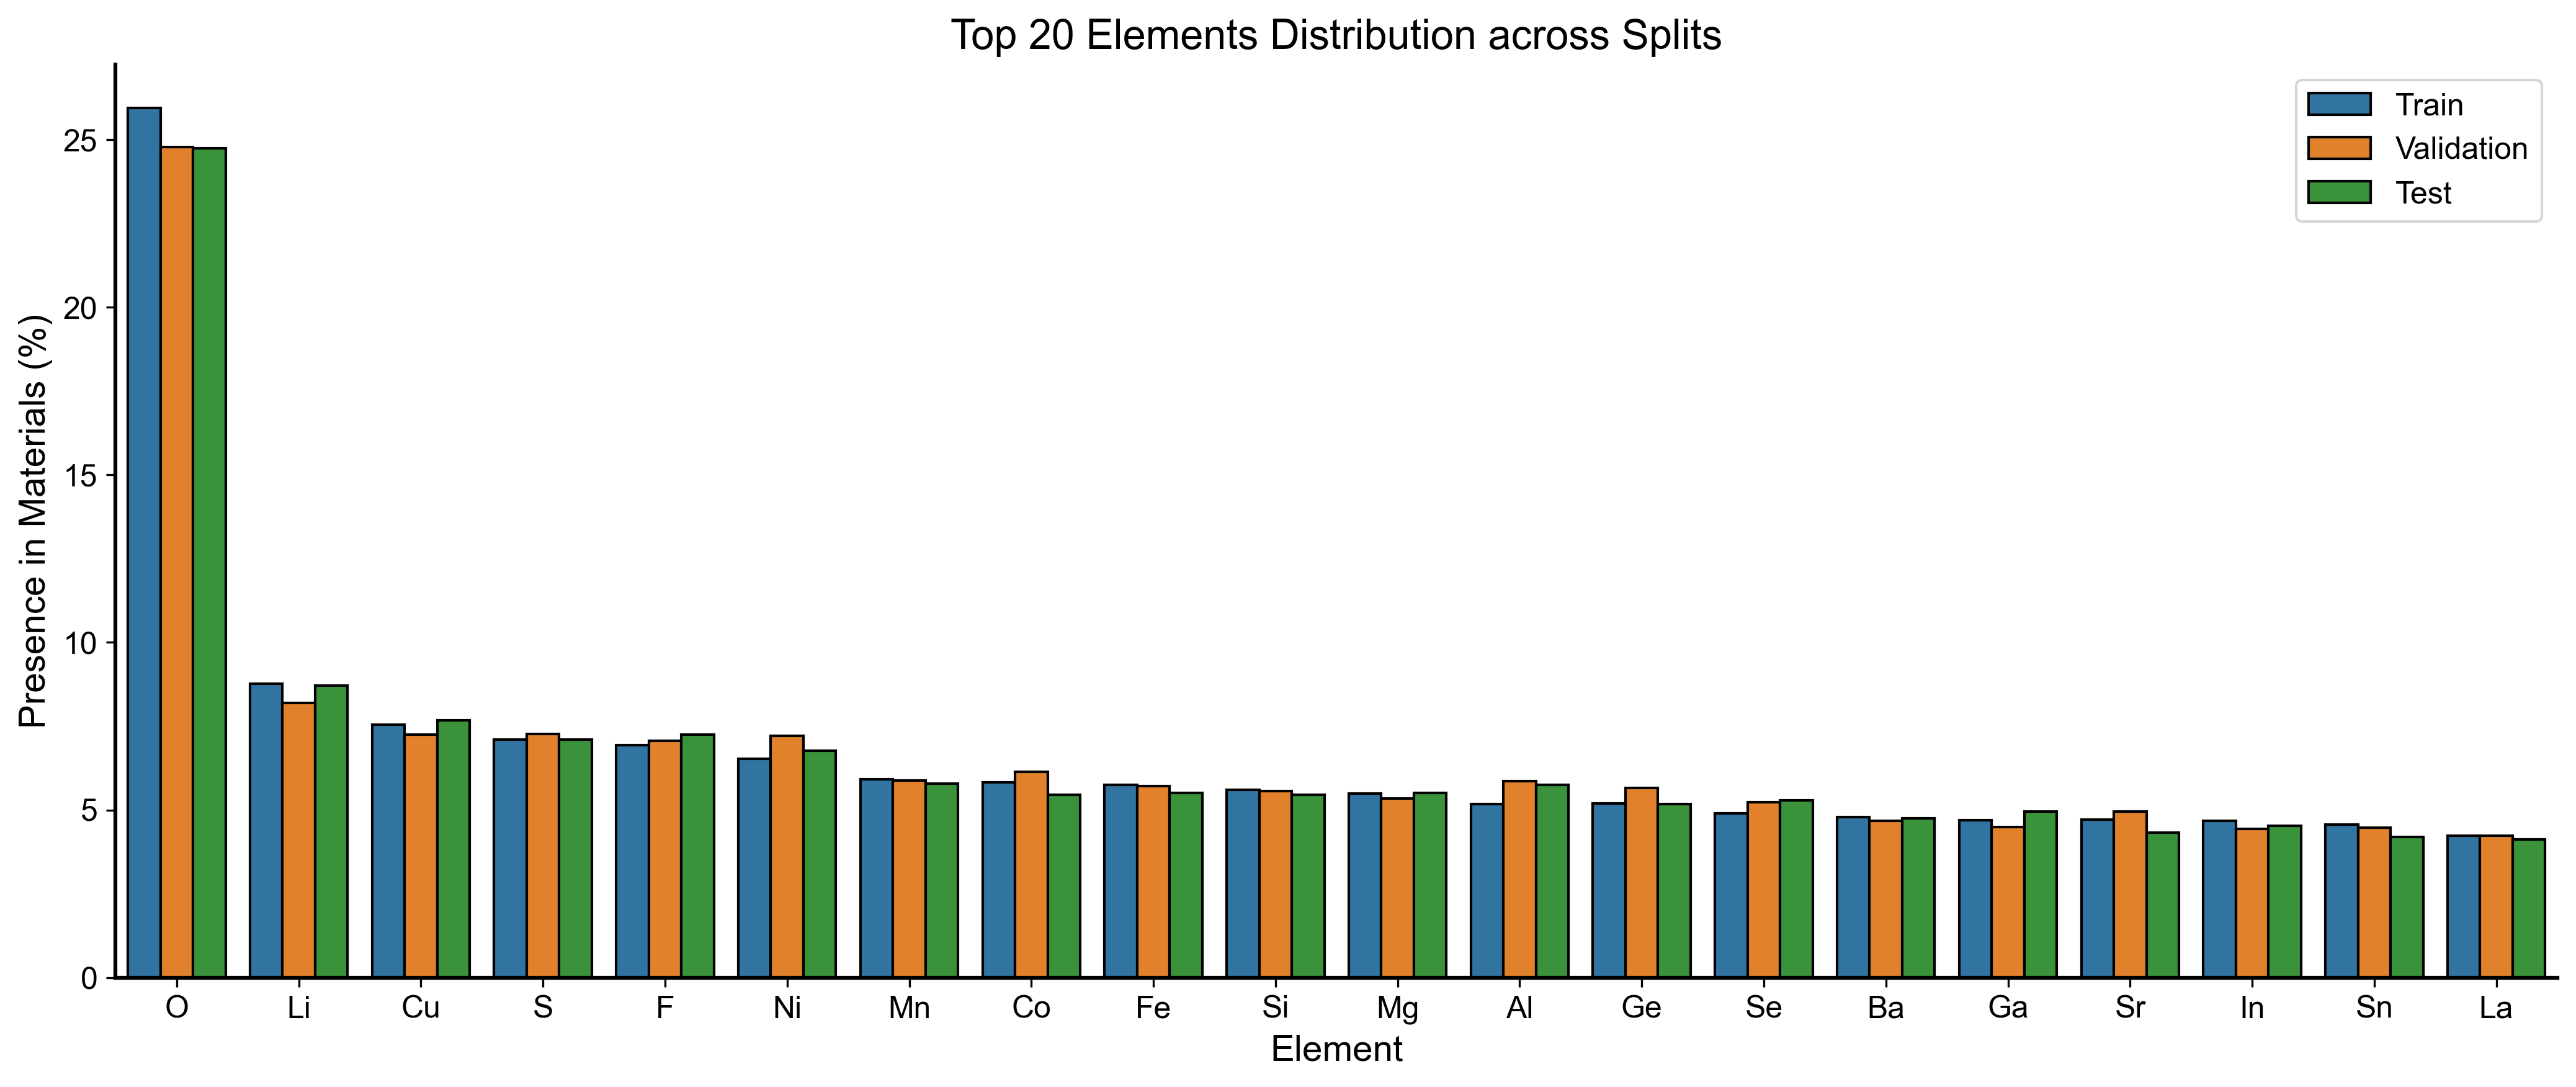

开始绘制组分复杂度分布图...
已保存组分复杂度分布图: compositional_complexity.pdf


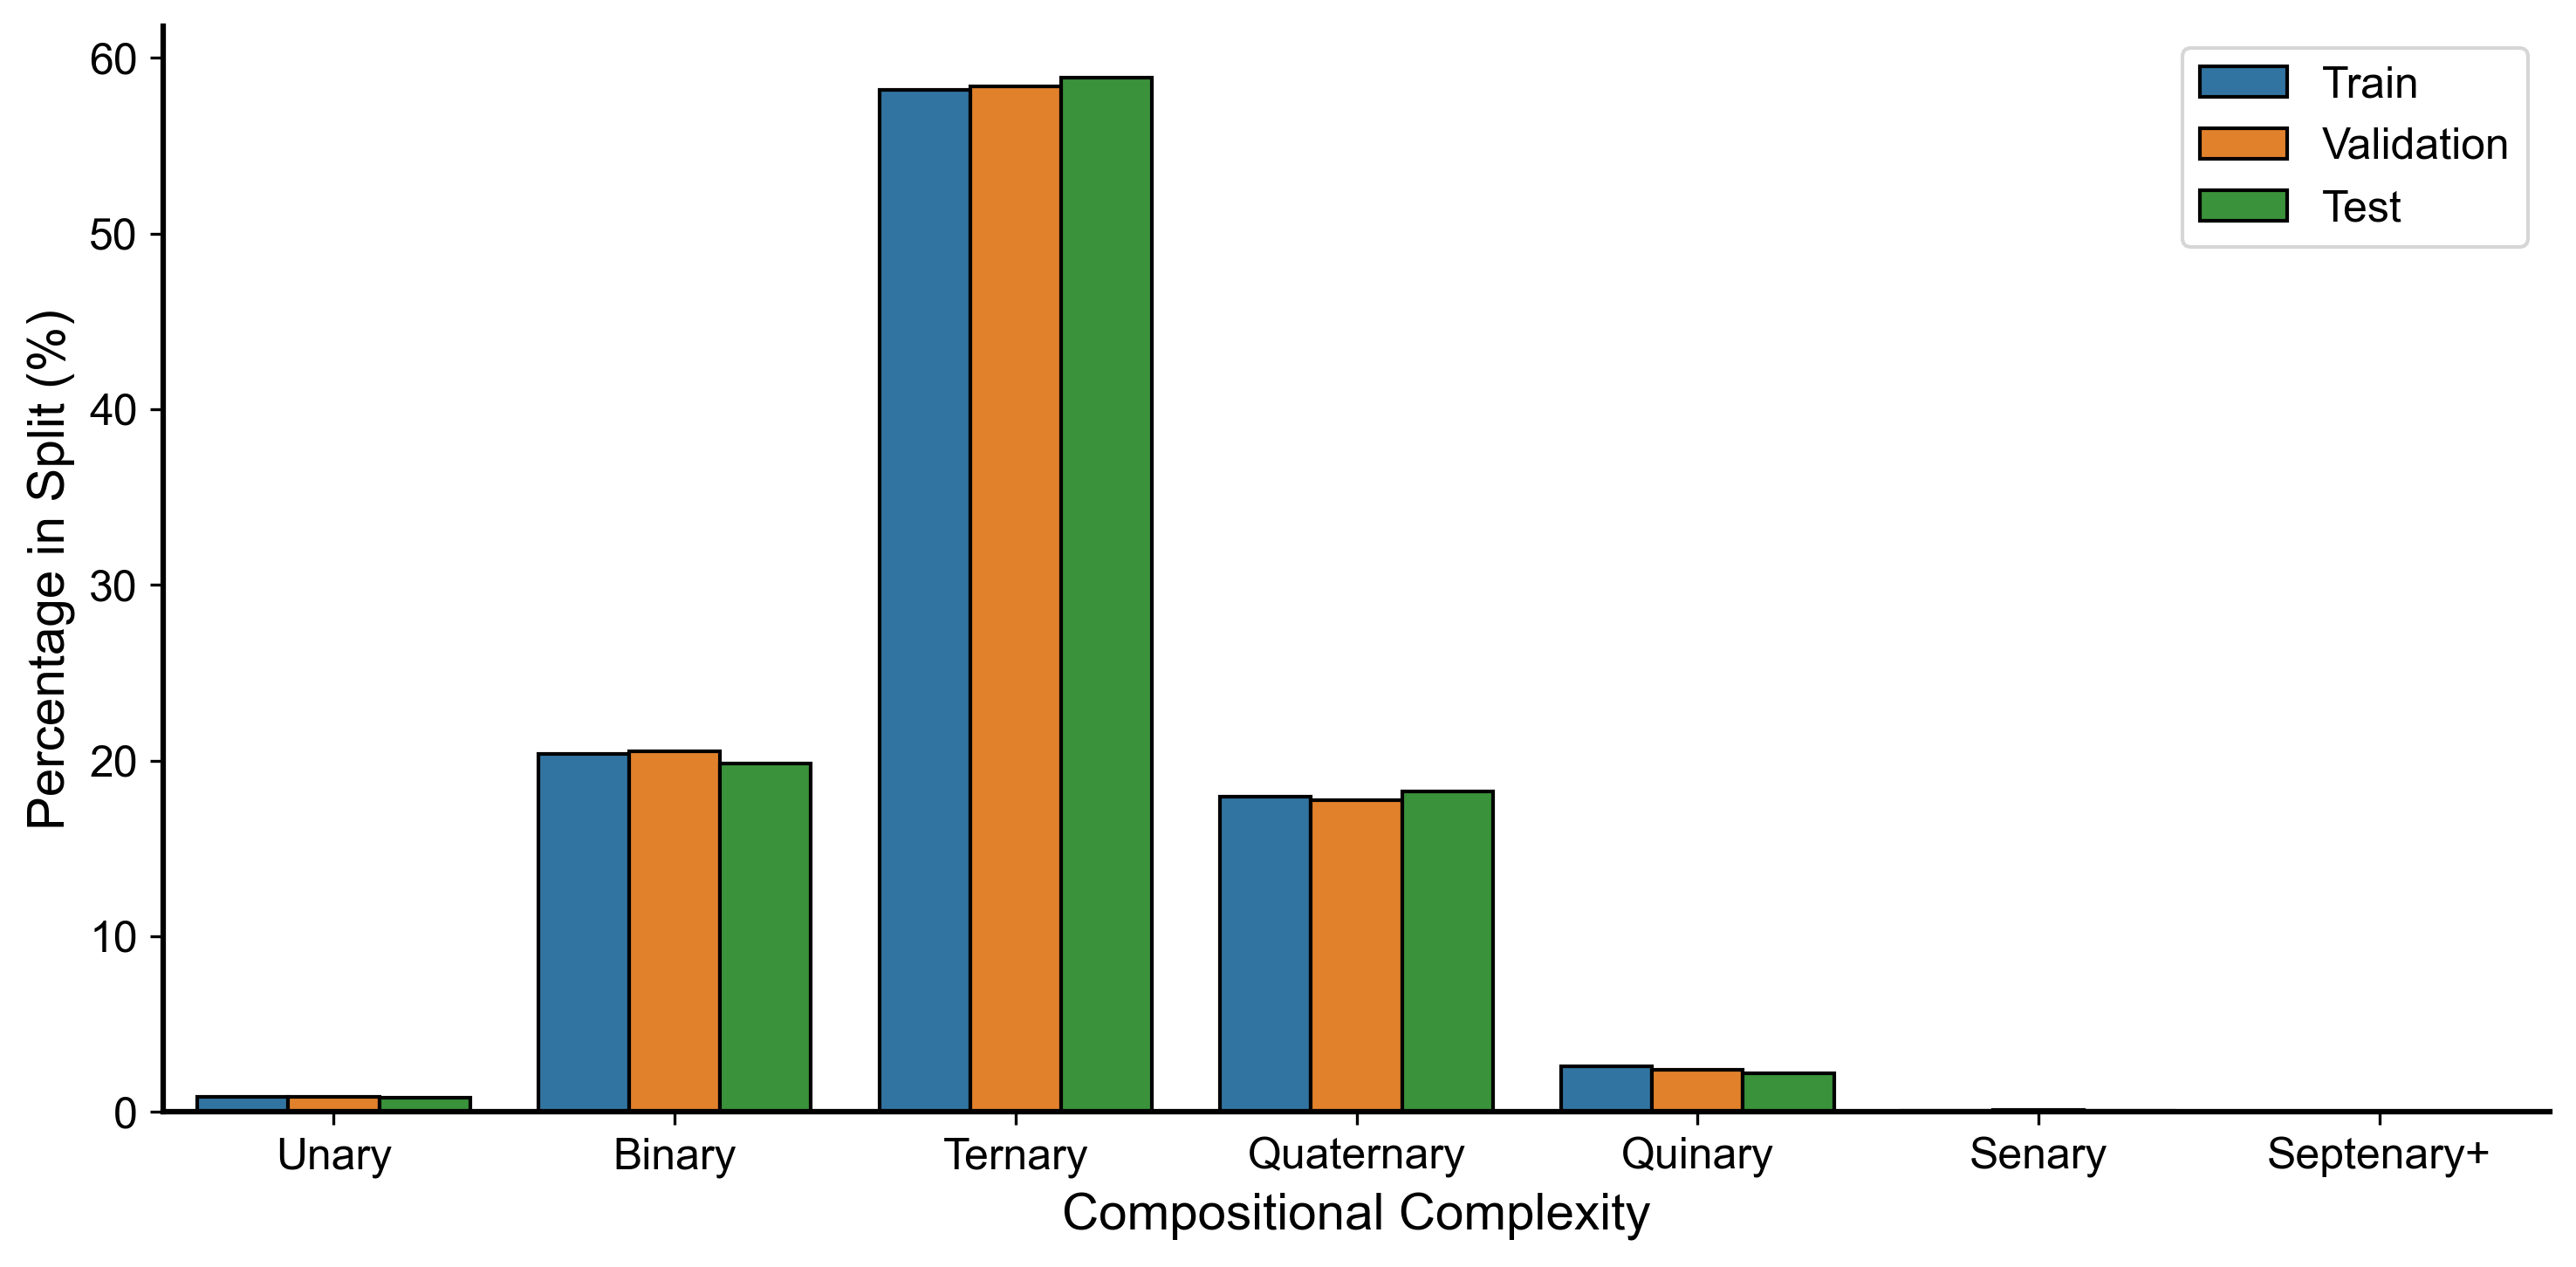

开始绘制结构原子数大小分布图...


C:\Users\12931\AppData\Local\Temp\ipykernel_66780\3431203608.py:366: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


已保存原子数统计图: atom_count_distribution.pdf


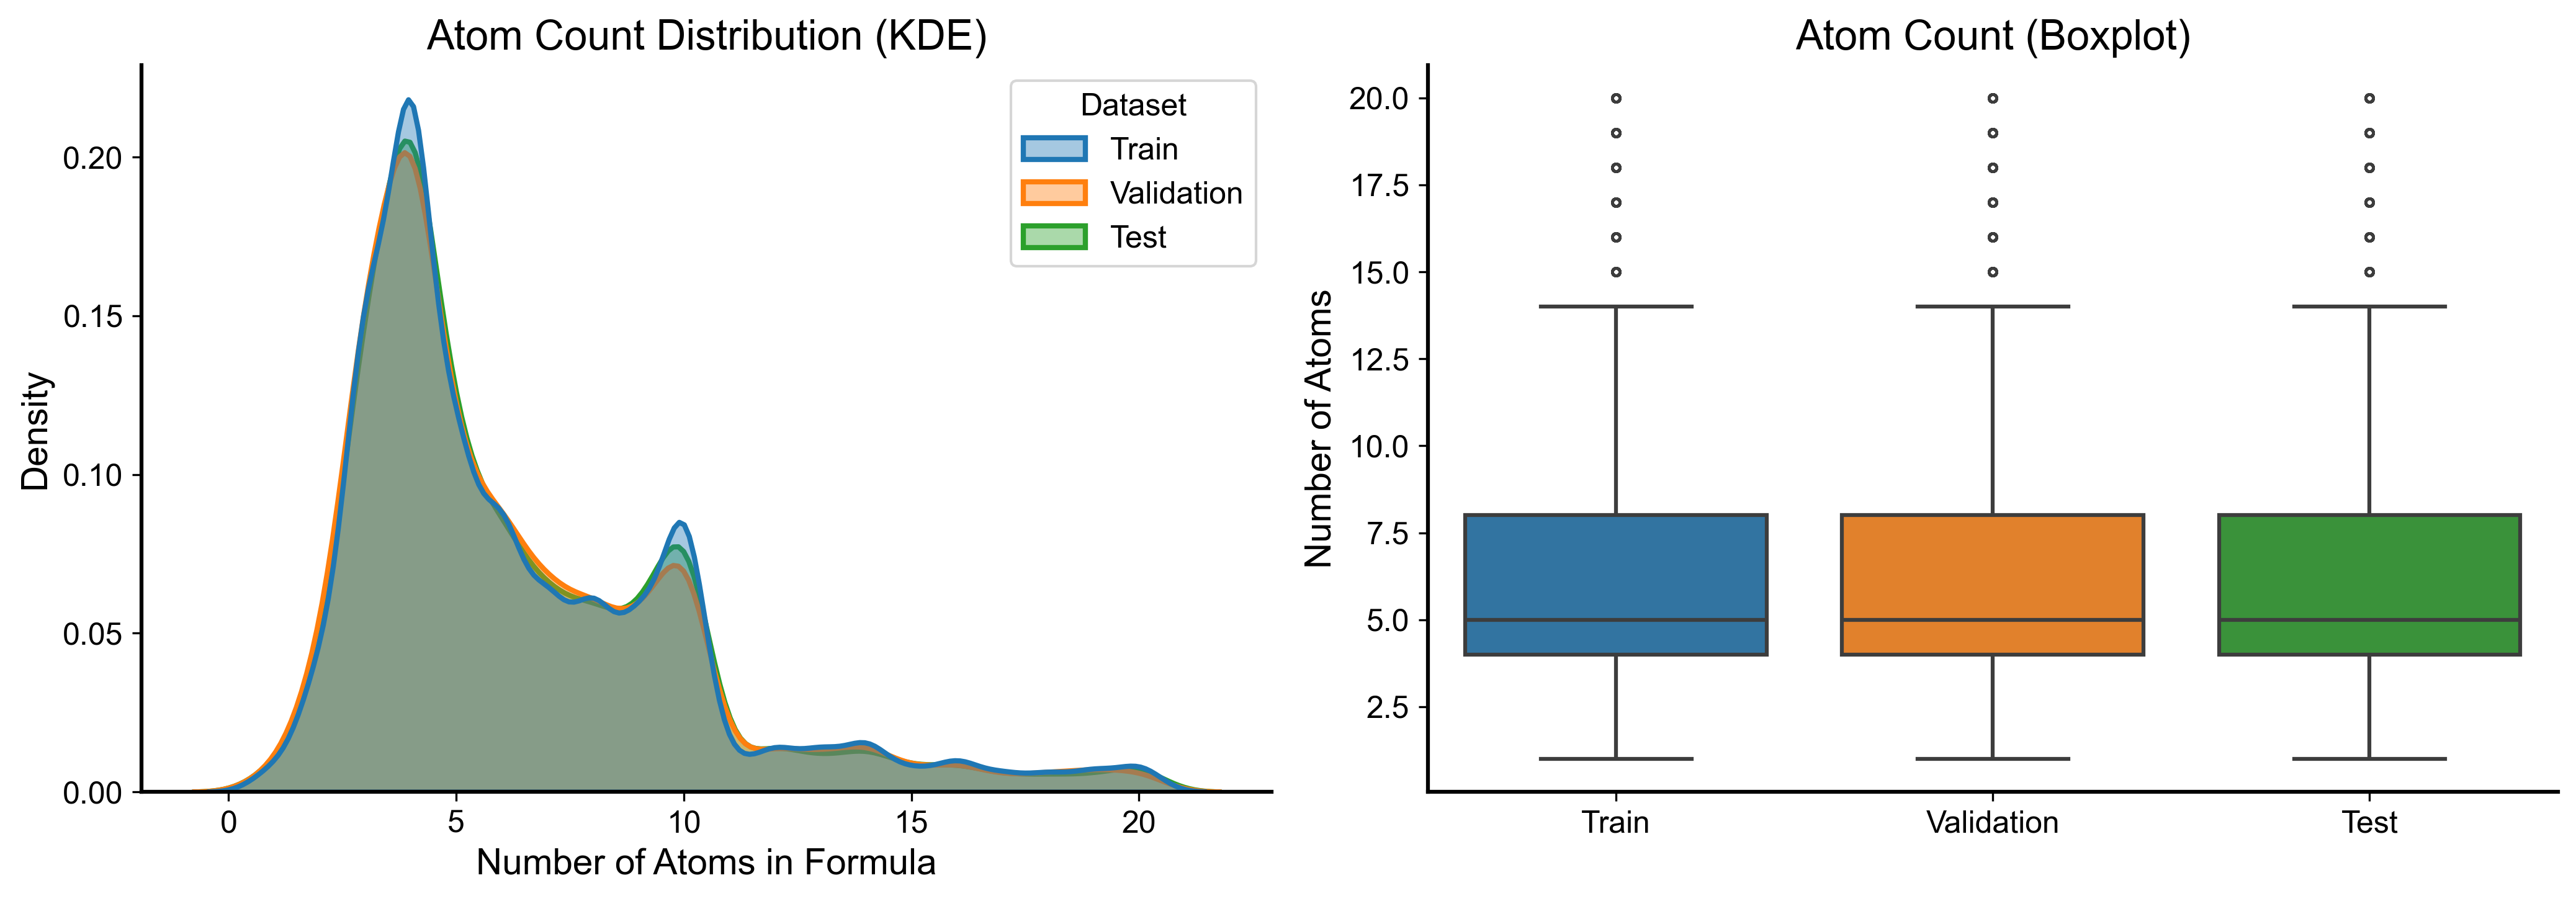

所有分析与绘图已完成。


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from collections import Counter
import os
import re

# ==========================================
# 1. 全局绘图样式设置 (可发表级别)
# ==========================================
# 使用基础的无网格线风格，适合学术论文
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 优先使用学术常用字体
    'axes.linewidth': 1.5,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300, # 高分辨率保存
    'savefig.dpi': 300,
    'savefig.bbox': 'tight' # 确保保存时边缘不被截断
})

# 定义统一的颜色盲友好色板 (Train, Val, Test)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 蓝, 橙, 绿

# ==========================================
# 2. 数据读取与预处理
# ==========================================
def load_and_prepare_data(train_path, val_path, test_path):
    """
    读取三个CSV文件并将它们合并，添加一个标识来源的列
    """
    try:
        df_train = pd.read_csv(train_path)
        df_val = pd.read_csv(val_path)
        df_test = pd.read_csv(test_path)
    except FileNotFoundError:
        print("警告: 找不到指定的CSV文件。为了演示，正在生成模拟数据...")
        return generate_mock_data()

    # 添加标签列
    df_train['Dataset'] = 'Train'
    df_val['Dataset'] = 'Validation'
    df_test['Dataset'] = 'Test'

    # 合并为一个大的 DataFrame 以便 seaborn 绘图
    df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
    return df_all, df_train, df_val, df_test

def generate_mock_data():
    """生成用于演示的模拟数据（如果用户没有提供真实路径）"""
    np.random.seed(42)
    def make_df(size, name):
        # 增加元素复杂度的多样性用于演示
        el_choices = [
            "['Fe']",                   # Unary
            "['O', 'Fe']",              # Binary
            "['Na', 'Mn', 'O']",        # Ternary
            "['Ba', 'Ti', 'O', 'Sr']",  # Quaternary
            "['Li', 'Co', 'Mn', 'Ni', 'O']" # Quinary
        ]
        # 增加对应的公式
        formula_choices = ["Fe", "Fe2O3", "Na3MnCoNiO6", "BaTiO3", "Li1.5Mn0.5Ni0.5O2"]
        df = pd.DataFrame({
            'formation_energy_per_atom': np.random.normal(loc=-1.5, scale=1.0, size=size),
            'band_gap': np.clip(np.random.normal(loc=1.0, scale=1.5, size=size), 0, None),
            'e_above_hull': np.clip(np.random.exponential(scale=0.1, size=size), 0, None),
            'spacegroup.number': np.random.choice([1, 12, 62, 166, 194, 221, 225, 227], size=size),
            'elements': np.random.choice(el_choices, size=size),
            'pretty_formula': np.random.choice(formula_choices, size=size),
            'Dataset': name
        })
        return df

    df_train = make_df(3000, 'Train')
    df_val = make_df(400, 'Validation')
    df_test = make_df(400, 'Test')
    df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
    return df_all, df_train, df_val, df_test

# ==========================================
# 3. 绘图函数
# ==========================================
def plot_property_distributions(df, save_dir='.'):
    """
    绘制形成能、带隙和 e_above_hull 在三个数据集中的概率密度分布 (KDE)
    """
    # 将子图数量从 2 改为 3，并适当加宽了画布
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 属性列表和对应的X轴标签
    properties = [
        ('formation_energy_per_atom', 'Formation Energy per Atom (eV/atom)'),
        ('band_gap', 'Band Gap (eV)'),
        ('e_above_hull', 'E above hull (eV/atom)')
    ]

    for ax, (prop, xlabel) in zip(axes, properties):
        # 使用 seaborn 绘制核密度图，用 hue 区分数据集
        sns.kdeplot(
            data=df, x=prop, hue='Dataset', hue_order=['Train', 'Validation', 'Test'],
            fill=True, common_norm=False, alpha=0.4, palette=colors, ax=ax, linewidth=2
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')

        # 去除上方和右侧的边框线 (学术图表常用)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'property_distributions.pdf'))
    plt.savefig(os.path.join(save_dir, 'property_distributions.png'))
    print("已保存属性分布图: property_distributions.pdf/png")
    plt.show()

def plot_spacegroup_distribution(df, save_dir='.', top_n=10):
    """
    绘制最常见的前N个空间群在三个数据集中的归一化频率分布
    """
    # 找出整体数据集中最常见的前 top_n 个空间群
    top_spacegroups = df['spacegroup.number'].value_counts().nlargest(top_n).index

    # 过滤数据并计算在各数据集中的百分比
    df_filtered = df[df['spacegroup.number'].isin(top_spacegroups)].copy()

    # 将 spacegroup 转换为字符串以便作为分类变量绘图
    df_filtered['spacegroup_str'] = df_filtered['spacegroup.number'].astype(int).astype(str)
    top_spacegroups_str = [str(int(sg)) for sg in top_spacegroups]

    # 计算相对比例
    prop_df = (df_filtered.groupby('Dataset')['spacegroup_str']
               .value_counts(normalize=True)
               .rename('Percentage')
               .mul(100)
               .reset_index())

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=prop_df, x='spacegroup_str', y='Percentage', hue='Dataset',
        hue_order=['Train', 'Validation', 'Test'], order=top_spacegroups_str,
        palette=colors, edgecolor='black', linewidth=1
    )

    plt.xlabel('Spacegroup Number')
    plt.ylabel('Percentage in Split (%)')
    plt.title(f'Top {top_n} Spacegroup Distributions')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.legend(title=None)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'spacegroup_distribution.pdf'))
    print("已保存空间群分布图: spacegroup_distribution.pdf")
    plt.show()

def parse_elements(element_str):
    """安全地将字符串格式的列表转换为真实列表"""
    try:
        return ast.literal_eval(element_str)
    except:
        return []

def plot_elements_frequency(df_train, df_val, df_test, save_dir='.', top_n=20):
    """
    分析并绘制元素在各个数据集中的出现频率（归一化百分比）
    """
    def get_element_counts(df):
        all_elements = []
        # 将 "['Co', 'Mn', 'Na', 'Ni', 'O']" 解析并展平
        for el_list_str in df['elements'].dropna():
            all_elements.extend(parse_elements(el_list_str))
        counts = Counter(all_elements)
        total_materials = len(df)
        # 计算该元素在多少个材料中出现过 (假设每个材料元素列表不重复)
        return {k: (v / total_materials) * 100 for k, v in counts.items()}

    train_el = get_element_counts(df_train)
    val_el = get_element_counts(df_val)
    test_el = get_element_counts(df_test)

    # 找出总体出现频率最高的前 N 个元素
    overall_counts = Counter()
    for el_list_str in pd.concat([df_train['elements'], df_val['elements'], df_test['elements']]).dropna():
        overall_counts.update(parse_elements(el_list_str))
    top_elements = [el for el, count in overall_counts.most_common(top_n)]

    # 准备绘图数据
    data = []
    for el in top_elements:
        data.append({'Element': el, 'Percentage': train_el.get(el, 0), 'Dataset': 'Train'})
        data.append({'Element': el, 'Percentage': val_el.get(el, 0), 'Dataset': 'Validation'})
        data.append({'Element': el, 'Percentage': test_el.get(el, 0), 'Dataset': 'Test'})

    df_el = pd.DataFrame(data)

    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=df_el, x='Element', y='Percentage', hue='Dataset',
        hue_order=['Train', 'Validation', 'Test'], palette=colors,
        edgecolor='black', linewidth=1
    )

    plt.xlabel('Element')
    plt.ylabel('Presence in Materials (%)')
    plt.title(f'Top {top_n} Elements Distribution across Splits')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.legend(title=None)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'elements_distribution.pdf'))
    print("已保存元素分布图: elements_distribution.pdf")
    plt.show()

def plot_property_boxplots(df, save_dir='.'):
    """
    绘制目标属性的箱线图，直观展示分位数和异常值分布
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    properties = [
        ('formation_energy_per_atom', 'Formation Energy per Atom (eV/atom)'),
        ('band_gap', 'Band Gap (eV)'),
        ('e_above_hull', 'E above hull (eV/atom)')
    ]

    for ax, (prop, ylabel) in zip(axes, properties):
        sns.boxplot(
            data=df, x='Dataset', y=prop,
            order=['Train', 'Validation', 'Test'],
            palette=colors, ax=ax, fliersize=3, linewidth=1.5
        )
        ax.set_xlabel('')
        ax.set_ylabel(ylabel)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'property_boxplots.pdf'))
    print("已保存属性箱线图: property_boxplots.pdf")
    plt.show()

def plot_property_correlation(df, save_dir='.'):
    """
    绘制带隙与形成能的二维联合分布散点图，检验多维特征空间的一致性
    """
    plt.figure(figsize=(8, 6))

    # 为了避免散点重叠过于严重，我们按 Test -> Val -> Train 的顺序画（小的在上面）
    # 同时使用 alpha 参数控制透明度
    for dataset, color in zip(['Train', 'Validation', 'Test'], colors):
        subset = df[df['Dataset'] == dataset]
        plt.scatter(
            subset['formation_energy_per_atom'], subset['band_gap'],
            label=dataset, color=color, alpha=0.5, s=15, edgecolors='none'
        )

    plt.xlabel('Formation Energy per Atom (eV/atom)')
    plt.ylabel('Band Gap (eV)')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 增加图例中的散点大小，便于查看
    plt.legend(title=None, markerscale=3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'property_correlation.pdf'))
    print("已保存二维属性相关性图: property_correlation.pdf")
    plt.show()

def plot_compositional_complexity(df, save_dir='.'):
    """
    绘制各个数据集中材料的组分复杂度（二元、三元、四元等）比例
    """
    df_comp = df.copy()
    # 计算每个材料的元素种类数量
    df_comp['num_elements'] = df_comp['elements'].apply(lambda x: len(parse_elements(x)) if pd.notnull(x) else 0)

    # 映射到标准的材料学化学名称
    name_map = {1: 'Unary', 2: 'Binary', 3: 'Ternary', 4: 'Quaternary', 5: 'Quinary', 6: 'Senary'}
    df_comp['Complexity'] = df_comp['num_elements'].map(lambda x: name_map.get(x, 'Septenary+'))

    # 统计比例（在各自的数据集中占比）
    comp_counts = (df_comp.groupby(['Dataset', 'Complexity'])
                   .size()
                   .groupby(level=0, group_keys=False) # 兼容pandas新版本
                   .apply(lambda x: 100 * x / float(x.sum()))
                   .reset_index(name='Percentage'))

    order = ['Unary', 'Binary', 'Ternary', 'Quaternary', 'Quinary', 'Senary', 'Septenary+']
    valid_order = [o for o in order if o in comp_counts['Complexity'].values]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=comp_counts, x='Complexity', y='Percentage', hue='Dataset',
        hue_order=['Train', 'Validation', 'Test'], order=valid_order,
        palette=colors, edgecolor='black', linewidth=1
    )
    plt.xlabel('Compositional Complexity')
    plt.ylabel('Percentage in Split (%)')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.legend(title=None)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'compositional_complexity.pdf'))
    print("已保存组分复杂度分布图: compositional_complexity.pdf")
    plt.show()

def get_num_atoms_from_formula(formula):
    """通过正则表达式解析化学式并计算包含的原子总数"""
    if pd.isnull(formula):
        return 0
    # 匹配 大写字母+小写字母(可选) + 数字(可选，支持小数)
    matches = re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', str(formula))
    total_atoms = 0
    for sym, num in matches:
        if num == '':
            total_atoms += 1
        else:
            total_atoms += float(num)
    return total_atoms

def plot_atom_count_distribution(df, save_dir='.'):
    """
    绘制结构中原子数的分布图，包含KDE分布和箱线图
    """
    if 'pretty_formula' not in df.columns:
        print("警告: 找不到 'pretty_formula' 列，跳过绘制原子数统计图。")
        return

    df_atoms = df.copy()
    df_atoms['num_atoms'] = df_atoms['pretty_formula'].apply(get_num_atoms_from_formula)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. KDE 分布图
    sns.kdeplot(
        data=df_atoms, x='num_atoms', hue='Dataset',
        hue_order=['Train', 'Validation', 'Test'],
        fill=True, common_norm=False, alpha=0.4, palette=colors, ax=axes[0], linewidth=2
    )
    axes[0].set_xlabel('Number of Atoms in Formula')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Atom Count Distribution (KDE)')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # 2. 箱线图 (查看极端大晶胞和均值差异)
    sns.boxplot(
        data=df_atoms, x='Dataset', y='num_atoms',
        order=['Train', 'Validation', 'Test'],
        palette=colors, ax=axes[1], fliersize=3, linewidth=1.5
    )
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Number of Atoms')
    axes[1].set_title('Atom Count (Boxplot)')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'atom_count_distribution.pdf'))
    print("已保存原子数统计图: atom_count_distribution.pdf")
    plt.show()

# ==========================================
# 4. 主执行流程
# ==========================================
if __name__ == "__main__":
    # ！！！请在这里替换为你真实的CSV文件路径！！！
    train_file = '../data/mp_20/train.csv'
    val_file = '../data/mp_20/val.csv'
    test_file = '../data/mp_20/test.csv'

    print("正在加载和处理数据...")
    df_all, df_train, df_val, df_test = load_and_prepare_data(train_file, val_file, test_file)

    print("开始绘制目标属性(KDE密度)分布图...")
    plot_property_distributions(df_all)

    print("开始绘制目标属性(Boxplot箱线)图...")
    plot_property_boxplots(df_all)

    print("开始绘制目标属性(二维相关性)散点图...")
    plot_property_correlation(df_all)

    if 'spacegroup.number' in df_all.columns:
        print("开始绘制空间群分布图...")
        plot_spacegroup_distribution(df_all)

    if 'elements' in df_all.columns:
        print("开始绘制元素频率分布图...")
        plot_elements_frequency(df_train, df_val, df_test)

        print("开始绘制组分复杂度分布图...")
        plot_compositional_complexity(df_all)

    if 'pretty_formula' in df_all.columns:
        print("开始绘制结构原子数大小分布图...")
        plot_atom_count_distribution(df_all)

    print("所有分析与绘图已完成。")

读取数据: ../output/singlerun/2026-03-10/evaluation_report.csv
✅ 成功过滤出 38 条匹配成功的数据。

🏆 论文表格：Top-10 生成保真度最高的结构 (Best 10)
 Index                                  Formula     RMSD  Volume_Error
   274  1T-AB-octa-11_0_1_2_4_6_7_9_10_11-NiSFe 0.017149         36.15
    80 1T-AB-octa-11_0_1_2_4_6_7_9_10_11-FeSeNb 0.018635         34.65
   241 1T-AB-octa-11_0_1_2_4_6_7_9_10_11-CoSeMn 0.022893         19.49
   128                2H-AA-prism-0_0_1_2-CoSeV 0.024541         24.94
   265  1T-AB-octa-11_0_1_2_4_6_7_9_10_11-MnSCo 0.029597         22.53
   280        1T-AA'-prism-0_0_1_2_4_5_6-CoTeMn 0.030724         41.99
   206  1T-AB-octa-11_0_1_2_4_6_7_9_10_11-CrTeW 0.031126         44.99
    34  1T-AB-octa-11_0_1_2_4_6_7_9_10_11-PdSeV 0.033913         52.21
   246        1T-AA'-prism-0_0_1_2_4_5_6-NiSeHf 0.033936         24.28
    26         2H-AB'-octa-0_0_1_2_4_5_6-TiSeZr 0.036149         21.21
已保存至: plots\Top10_Best_Structures.csv

📊 论文报告核心统计指标 (Summary)
成功匹配样本数: 38
中位 RMSD (Median RMSD): 0.0575

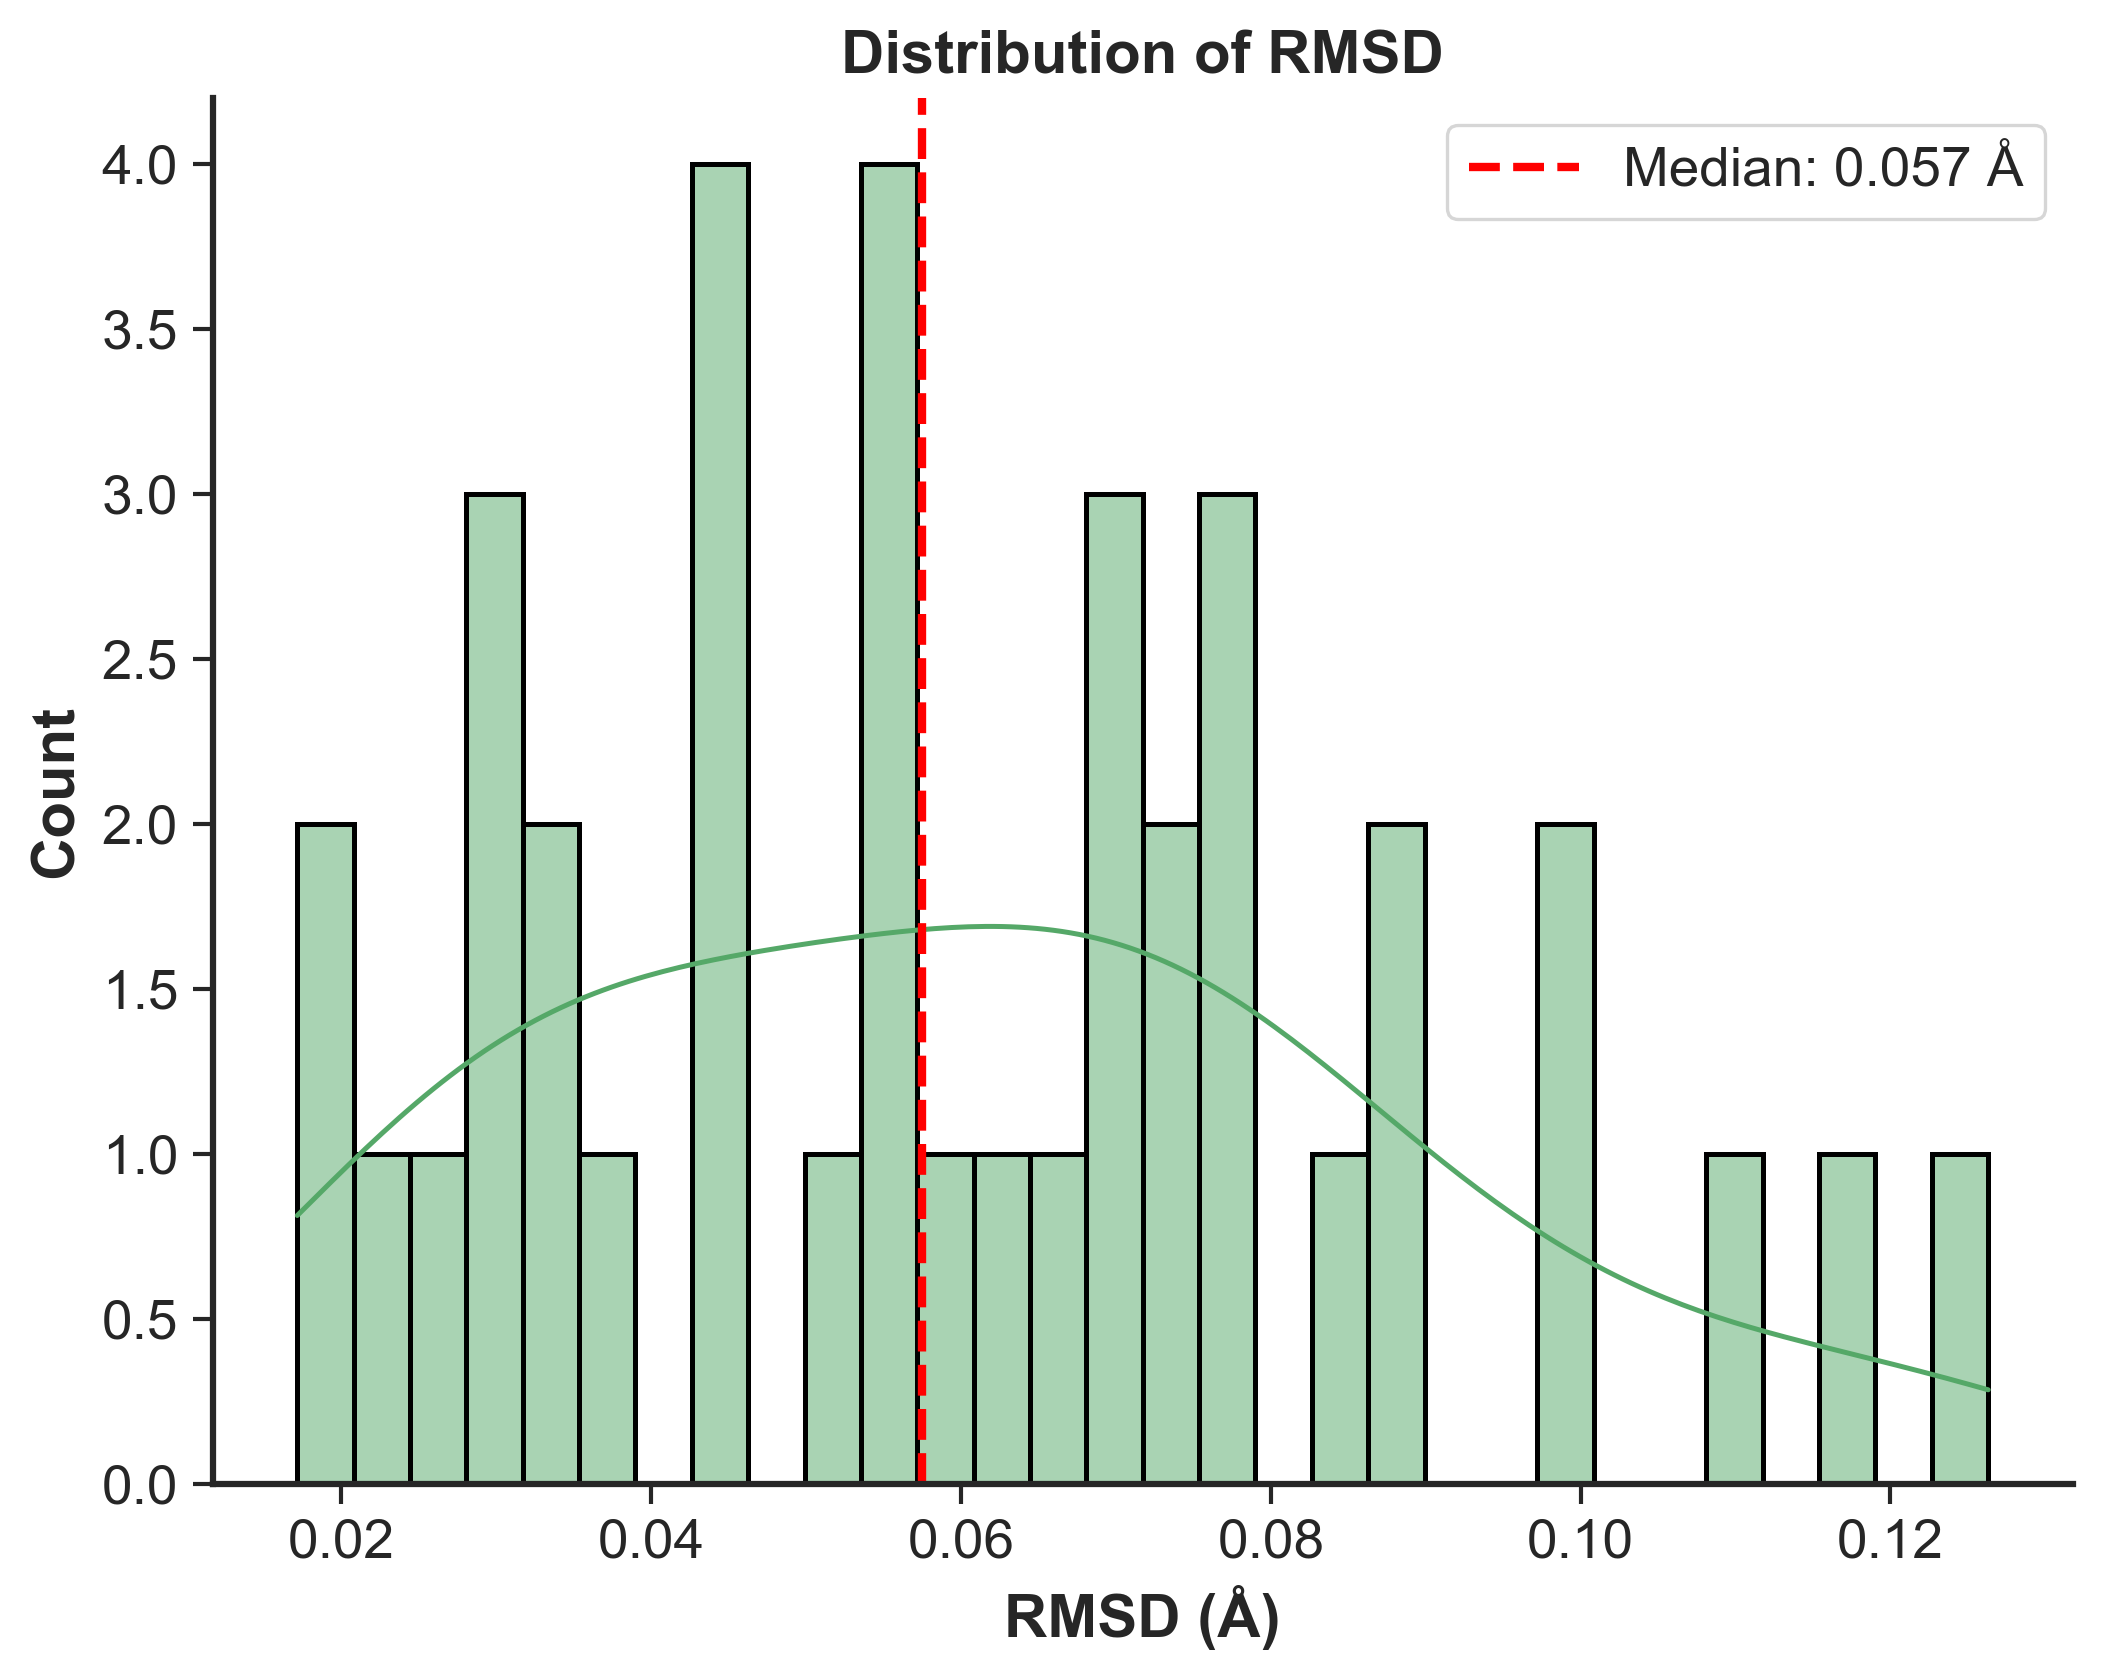

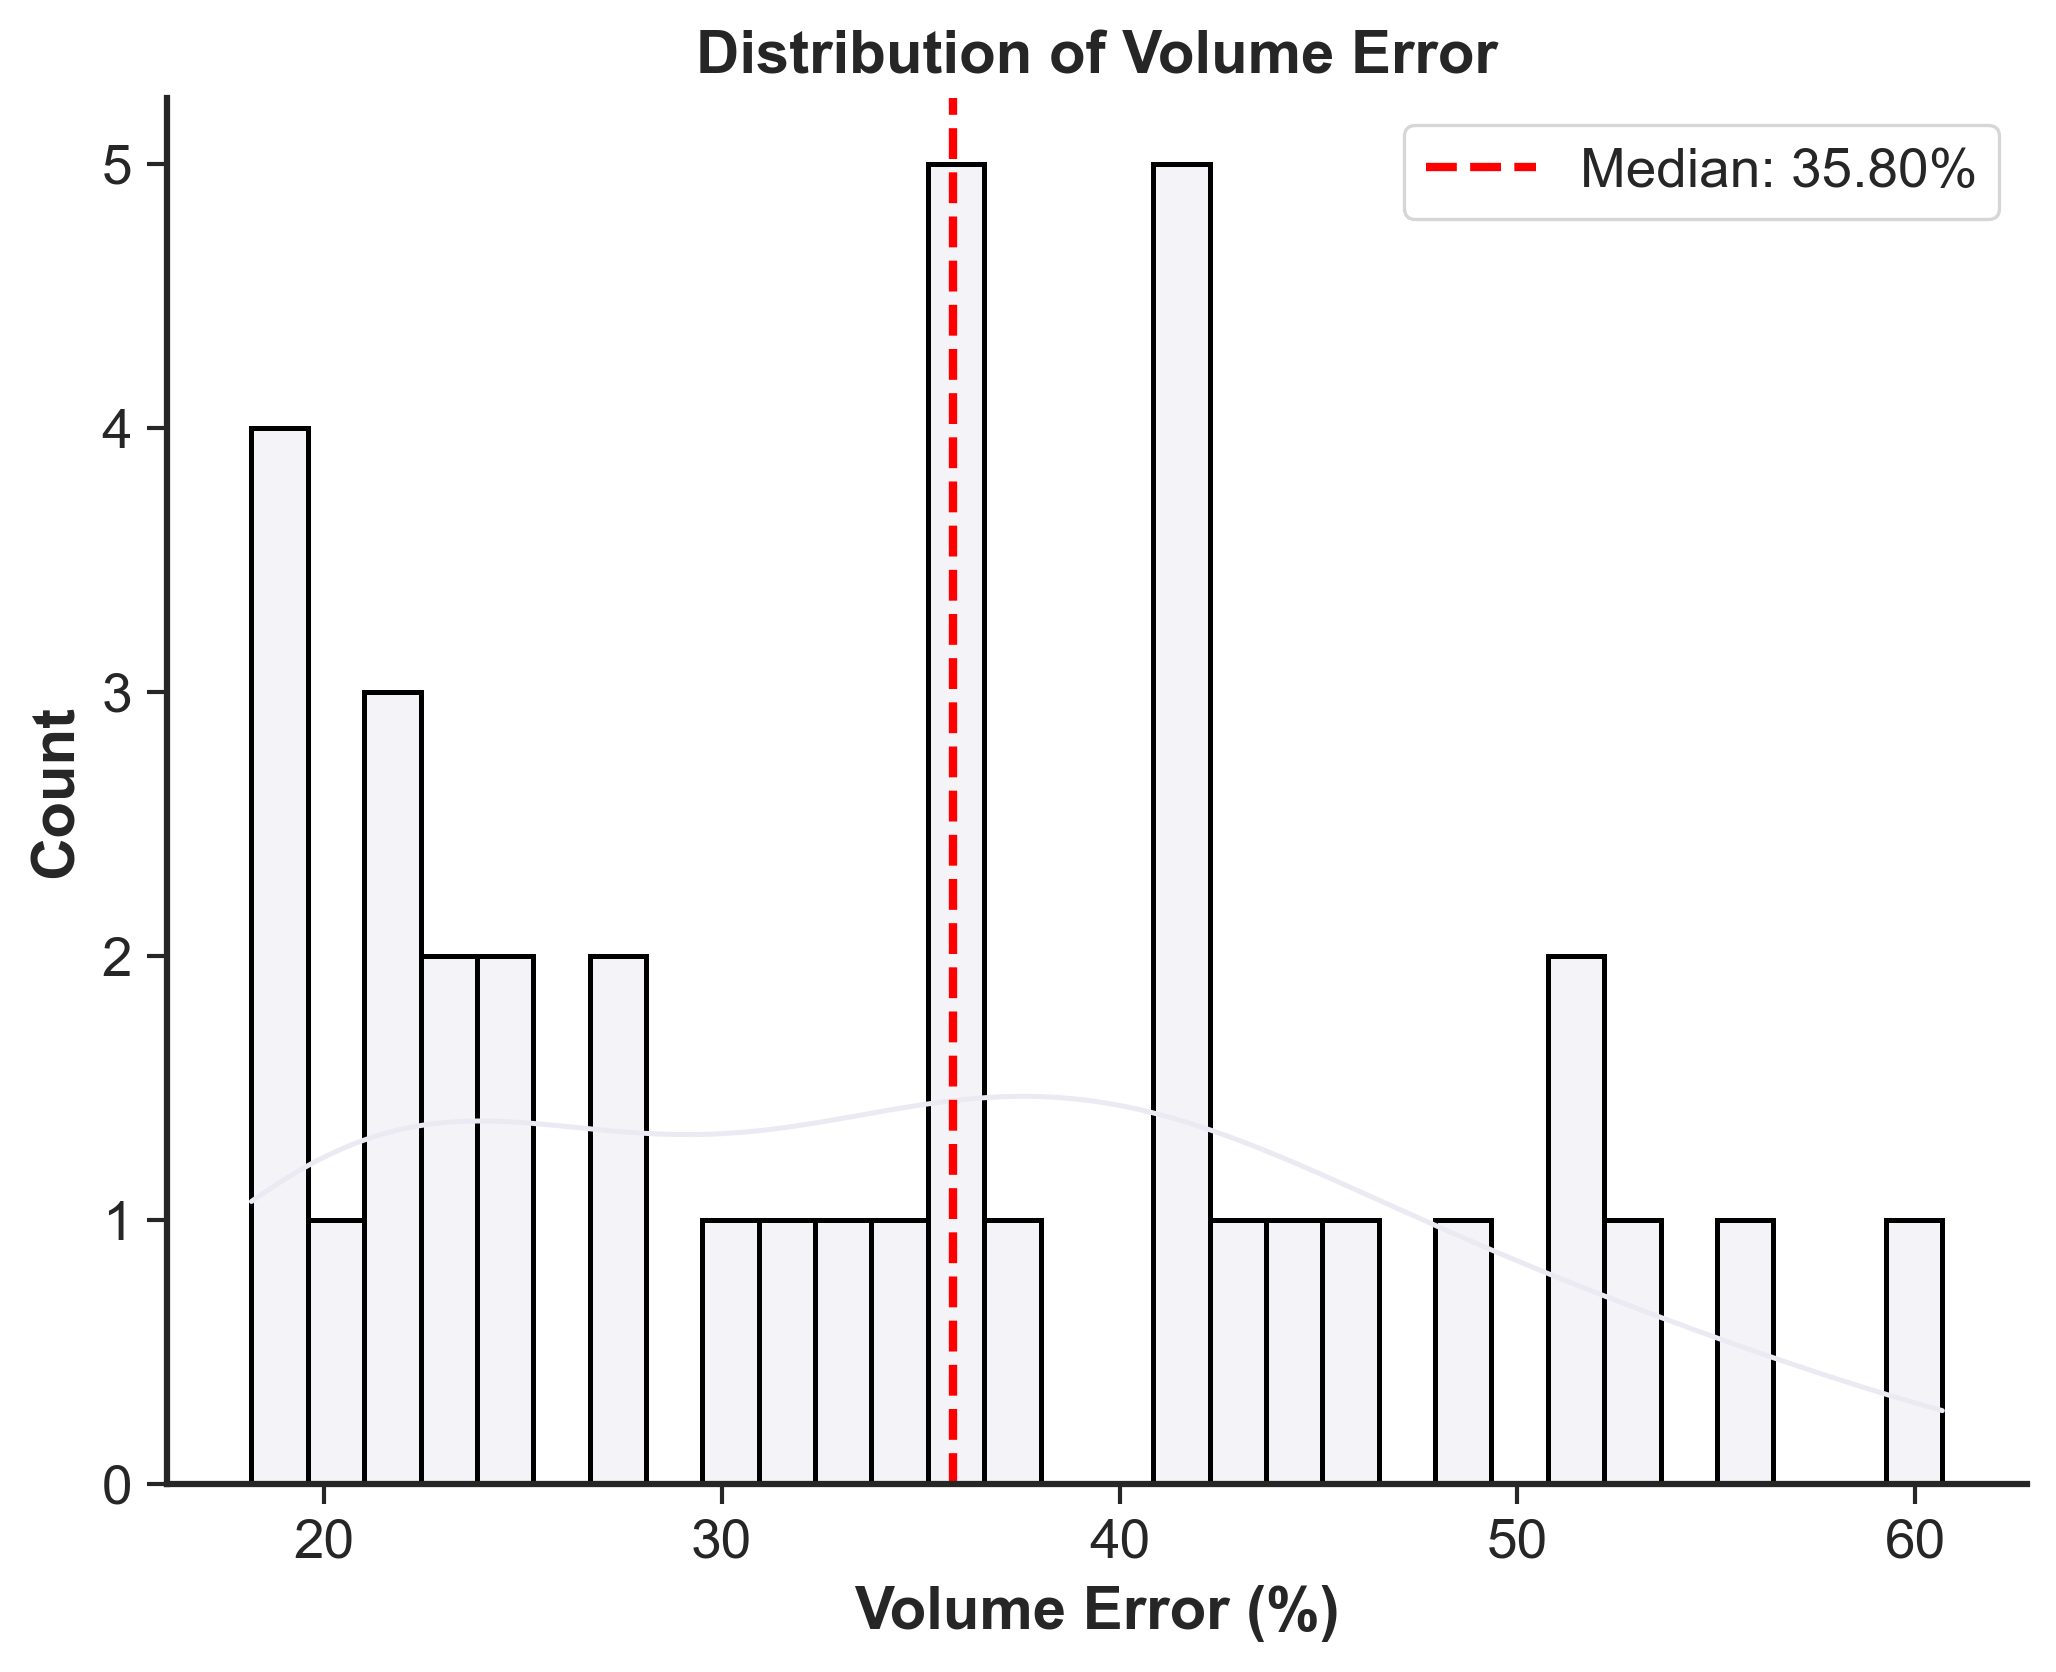

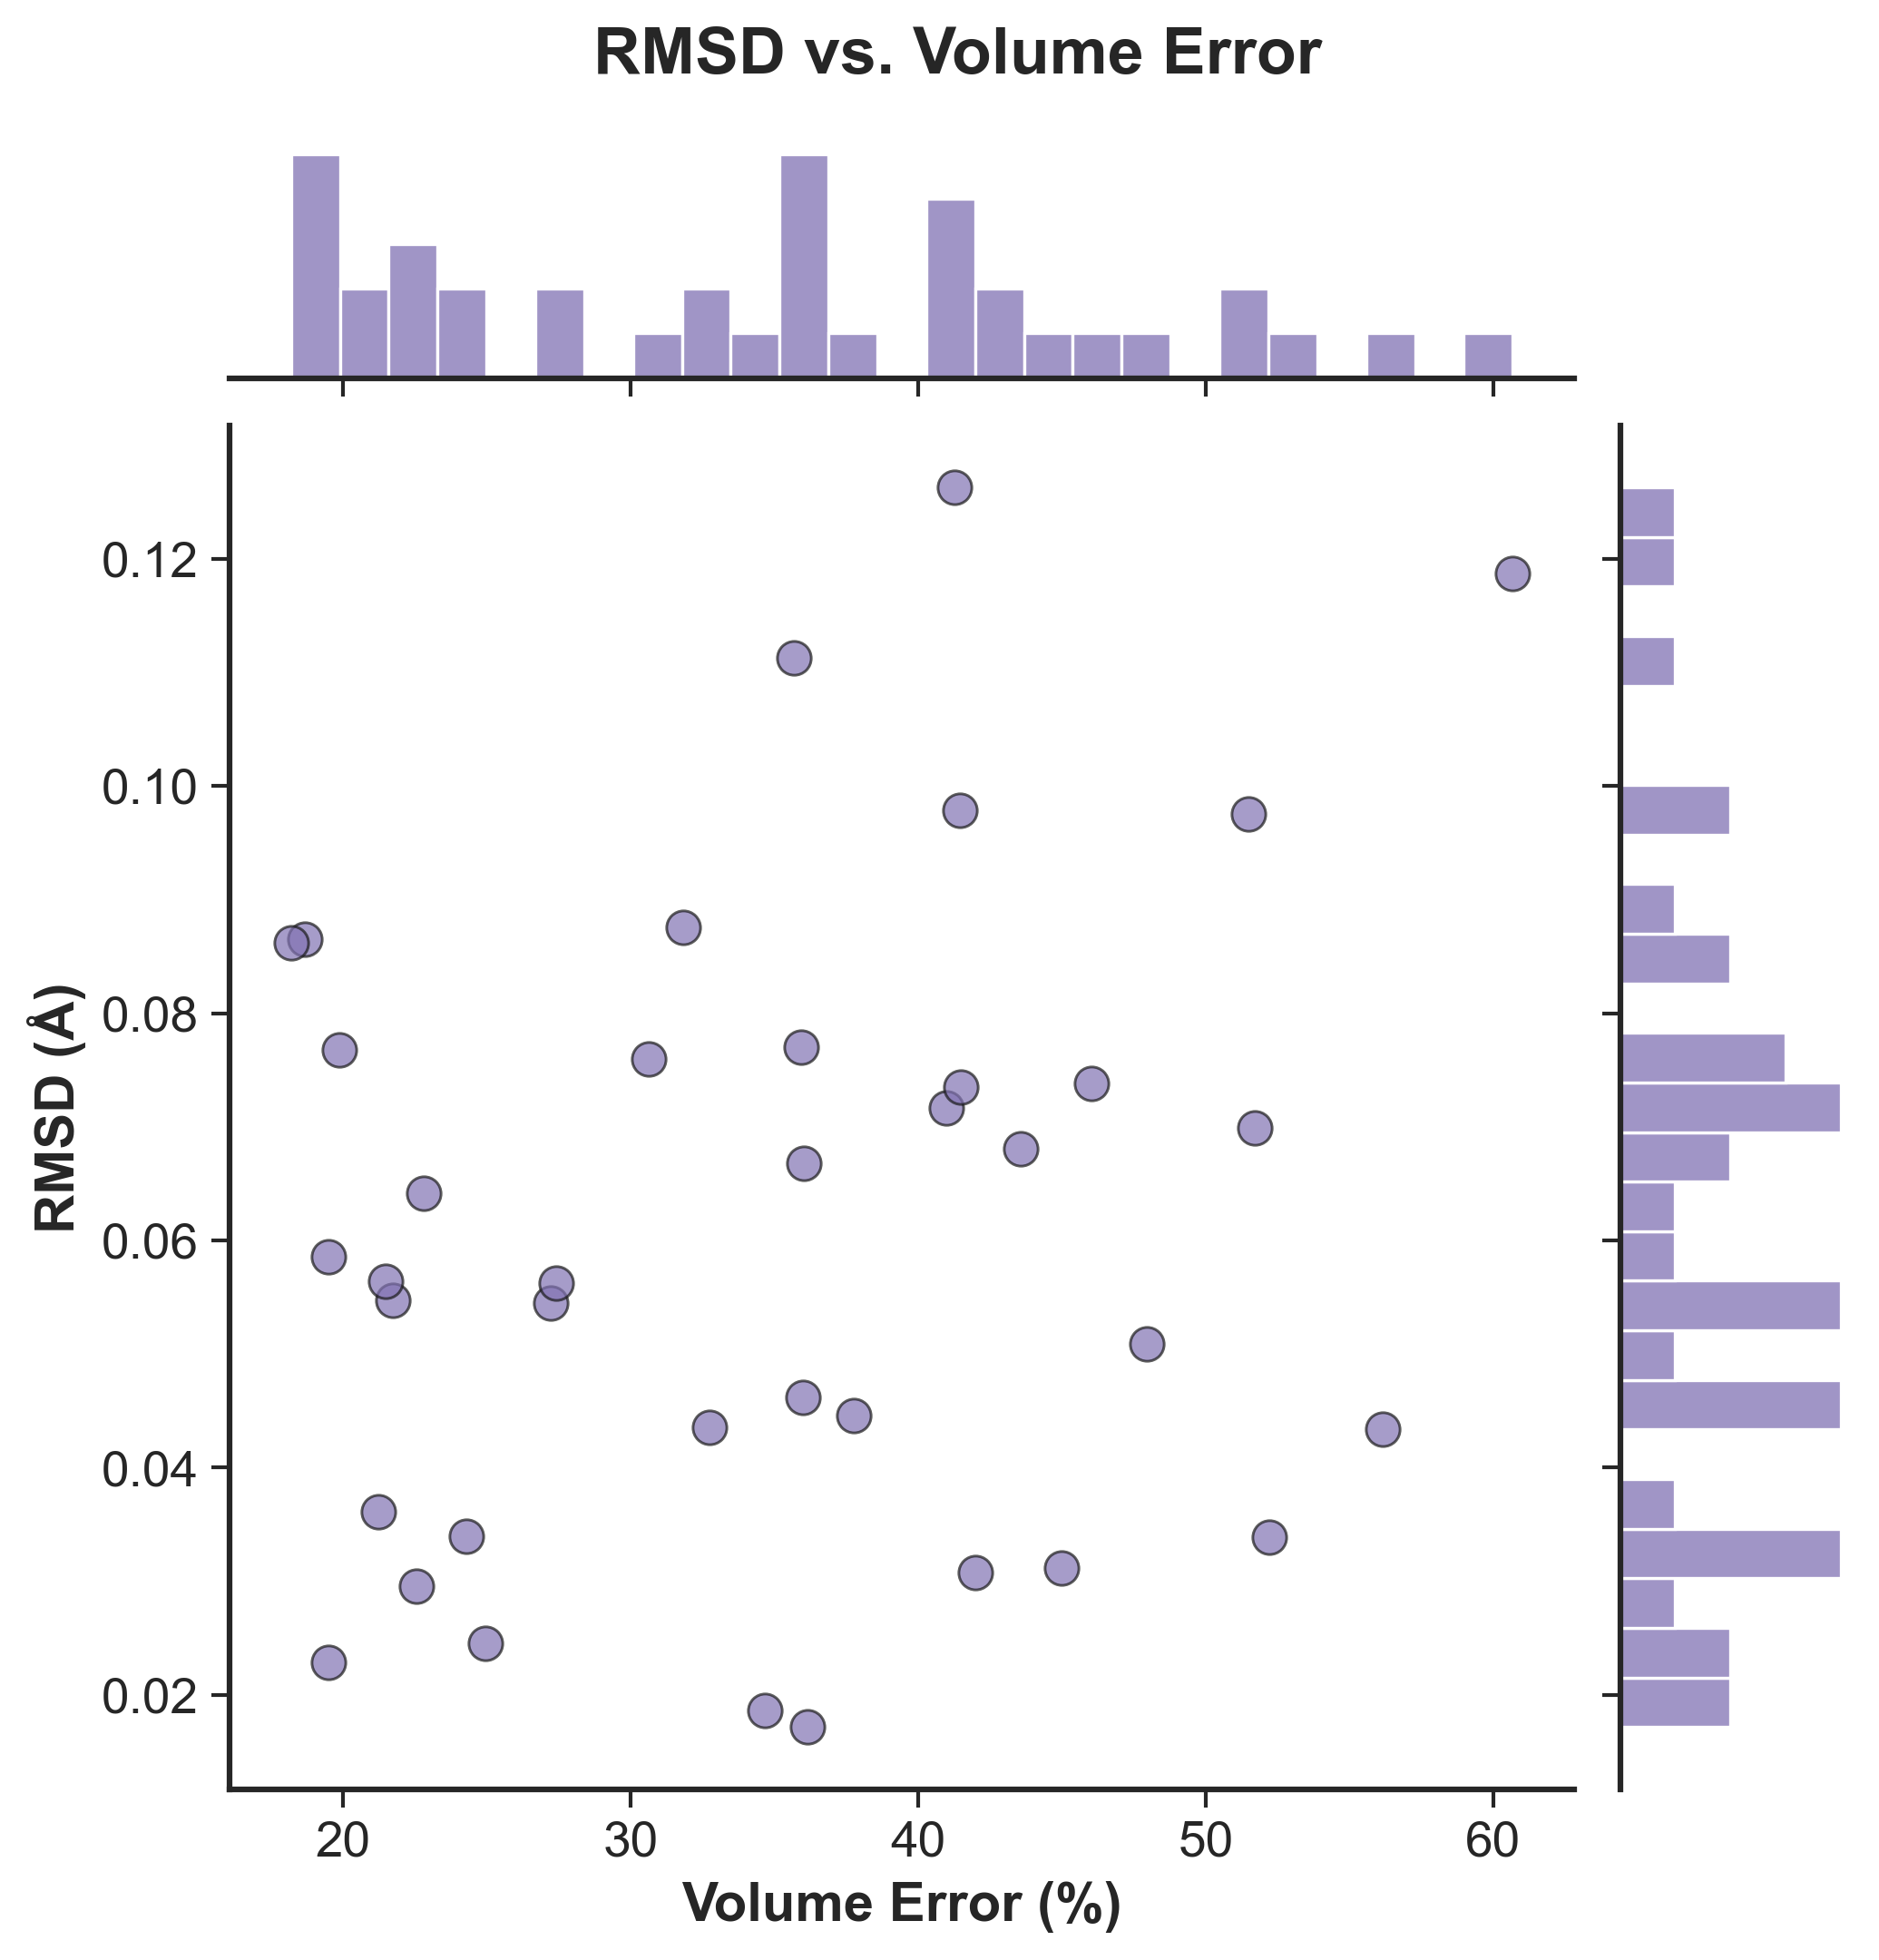

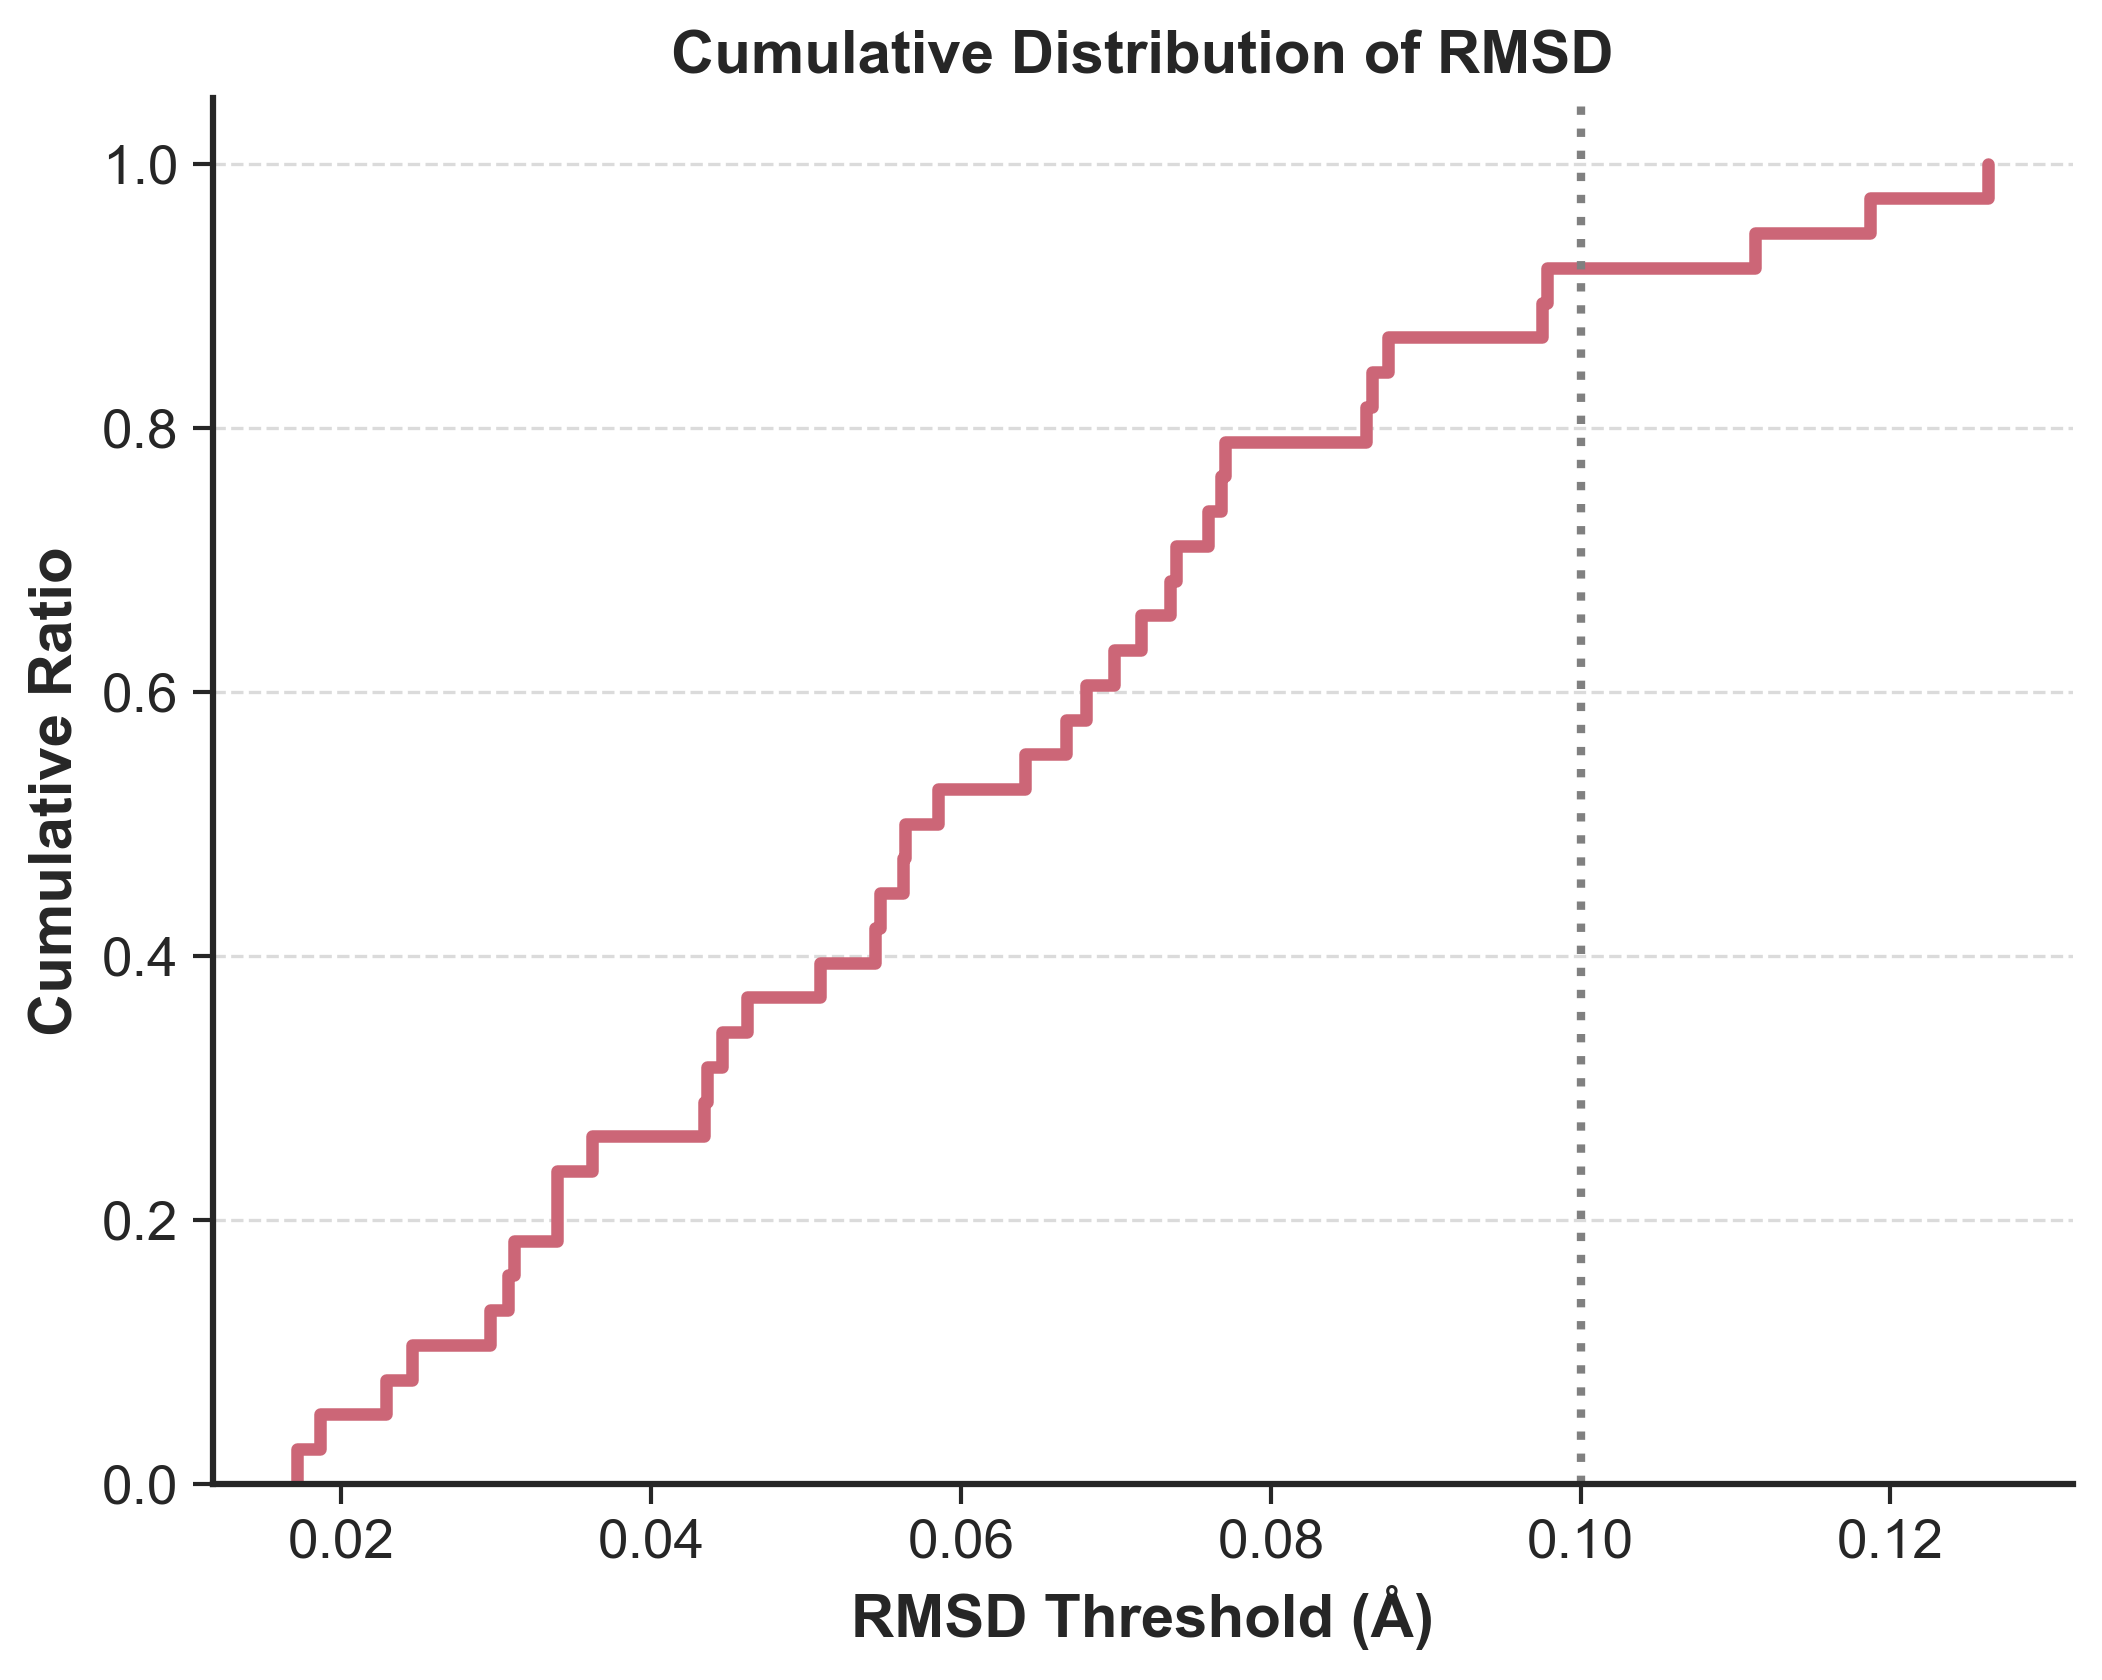


✅ 所有图表已生成完毕，并保存在文件夹: E:\WORKSPACE\CodePlace\test_CGDiT\post_processing\plots


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

def analyze_and_plot(csv_path, output_dir="plots"):
    """分析评估报告并生成用于发表的图表"""
    os.makedirs(output_dir, exist_ok=True)

    # 1. 读取数据
    print(f"读取数据: {csv_path}")
    df = pd.read_csv(csv_path)

    # 2. 仅保留匹配成功的数据
    df_matched = df[df['Is_Match'] == True].copy()
    matched_samples = len(df_matched)

    if matched_samples == 0:
        print("没有找到匹配成功的数据，无法进行后续分析！")
        return

    print(f"✅ 成功过滤出 {matched_samples} 条匹配成功的数据。")

    # 保存一份只包含成功匹配数据的 CSV，方便查看
    filtered_csv_path = os.path.join(output_dir, "matched_only_report.csv")
    df_matched.to_csv(filtered_csv_path, index=False)

    # 数据清洗
    df_matched['Volume_Error'] = df_matched['Volume_Error'].astype(str).str.replace('%', '')
    df_matched['Volume_Error'] = pd.to_numeric(df_matched['Volume_Error'], errors='coerce')
    df_matched['RMSD'] = pd.to_numeric(df_matched['RMSD'], errors='coerce')

    # 3. 计算核心统计指标 (用于论文表格)
    median_rmsd = df_matched['RMSD'].median()
    median_vol_error = df_matched['Volume_Error'].median()

    # --- 新增：提取 Top-10 生成质量最高的数据 ---
    top_10_df = df_matched.nsmallest(10, 'RMSD')[['Index', 'Formula', 'RMSD', 'Volume_Error']]
    top_10_path = os.path.join(output_dir, "Top10_Best_Structures.csv")
    top_10_df.to_csv(top_10_path, index=False)

    print("\n" + "="*50)
    print("🏆 论文表格：Top-10 生成保真度最高的结构 (Best 10)")
    print("="*50)
    print(top_10_df.to_string(index=False))
    print(f"已保存至: {top_10_path}")

    print("\n" + "="*50)
    print("📊 论文报告核心统计指标 (Summary)")
    print("="*50)
    print(f"成功匹配样本数: {matched_samples}")
    print(f"中位 RMSD (Median RMSD): {median_rmsd:.4f} Å")
    print(f"中位体积误差 (Median Volume Error): {median_vol_error:.2f}%")
    print("="*50 + "\n")

    # ==========================================
    # 开始绘图 (设置全局绘图风格为学术风)
    # ==========================================
    sns.set_theme(style="ticks", context="paper", font_scale=1.5)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.linewidth'] = 1.5

    # [图 1] RMSD 分布密度/直方图
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    sns.histplot(df_matched['RMSD'].dropna(), bins=30, kde=True, color='#55A868',
                 edgecolor='black', linewidth=1.2, ax=ax1)
    ax1.axvline(median_rmsd, color='red', linestyle='dashed', linewidth=2,
                label=f'Median: {median_rmsd:.3f} Å')
    ax1.set_xlabel('RMSD (Å)', fontweight='bold')
    ax1.set_ylabel('Count', fontweight='bold')
    ax1.set_title('Distribution of RMSD', fontweight='bold')
    ax1.legend()
    sns.despine()
    plt.savefig(os.path.join(output_dir, 'Fig1_RMSD_Distribution.pdf'), bbox_inches='tight', dpi=300)
    plt.show() # 直接展示

    # [图 2] 体积误差分布图
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sns.histplot(df_matched['Volume_Error'].dropna(), bins=30, kde=True, color='#EAEAF2',
                 edgecolor='black', linewidth=1.2, ax=ax2)
    ax2.axvline(median_vol_error, color='red', linestyle='dashed', linewidth=2,
                label=f'Median: {median_vol_error:.2f}%')
    ax2.set_xlabel('Volume Error (%)', fontweight='bold')
    ax2.set_ylabel('Count', fontweight='bold')
    ax2.set_title('Distribution of Volume Error', fontweight='bold')
    ax2.legend()
    sns.despine()
    plt.savefig(os.path.join(output_dir, 'Fig2_Volume_Error_Distribution.pdf'), bbox_inches='tight', dpi=300)
    plt.show() # 直接展示

    # [图 3] RMSD vs 体积误差 的散点图 (联合分布更专业)
    # 使用 jointplot 替换单纯的 scatterplot，附带边缘直方图，学术感更强
    g = sns.jointplot(x='Volume_Error', y='RMSD', data=df_matched,
                      color='#8172B3', alpha=0.7, edgecolor='k', s=80,
                      height=7, marginal_kws=dict(bins=25, fill=True))
    g.set_axis_labels('Volume Error (%)', 'RMSD (Å)', fontweight='bold')
    g.fig.suptitle('RMSD vs. Volume Error', fontweight='bold', y=1.03)
    plt.savefig(os.path.join(output_dir, 'Fig3_RMSD_vs_Volume_Error.pdf'), bbox_inches='tight', dpi=300)
    plt.show() # 直接展示

    # --- 新增: [图 4] RMSD 的累积分布函数 (CDF) 图 ---
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    sns.ecdfplot(data=df_matched, x='RMSD', color='#CC6677', linewidth=3, ax=ax4)
    # 画辅助线：例如关注 RMSD < 0.1 埃的高精度比例
    ax4.axvline(0.1, color='gray', linestyle=':', linewidth=2)
    ax4.set_xlabel('RMSD Threshold (Å)', fontweight='bold')
    ax4.set_ylabel('Cumulative Ratio', fontweight='bold')
    ax4.set_title('Cumulative Distribution of RMSD', fontweight='bold')

    # 将 y 轴设置为 0-1 的比例，并添加网格线使其更易读
    ax4.set_ylim(0, 1.05)
    ax4.grid(axis='y', linestyle='--', alpha=0.7)
    sns.despine()
    plt.savefig(os.path.join(output_dir, 'Fig4_RMSD_CDF_Plot.pdf'), bbox_inches='tight', dpi=300)
    plt.show() # 直接展示

    print(f"\n✅ 所有图表已生成完毕，并保存在文件夹: {os.path.abspath(output_dir)}")

if __name__ == "__main__":
    # 请根据实际路径修改这里的 csv_path
    csv_file_path = "../output/singlerun/2026-03-10/evaluation_report.csv"

    if os.path.exists(csv_file_path):
        analyze_and_plot(csv_file_path)
    else:
        print(f"找不到文件: {csv_file_path}，请检查路径是否正确。")